In [1]:
import matplotlib.pyplot as plt
import muon as mu
import numpy as np
import os
import pandas as pd
import scanpy as sc
import scipy.stats as stats
import sys
from matplotlib.colors import ListedColormap
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import accuracy_score, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor

/home/maxi7524/micromamba/envs/bio_env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/maxi7524/micromamba/envs/bio_env/lib/python3.13/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


# Small project

- Total: 10 points. 
- Work in groups of 1 or 2 **(for groups of 2, list each member's individual contributions).**
- Submit: one runnable `.ipynb` with code, figures, and conclusions.
- Deadline: 07.06.2026 23:59

You will compare a multi-view factor model (MOFA) against single-view MOFA/PCA in two settings: a controlled simulation where you know the ground truth, and a real multi-omics dataset of your choice. The point of the exercise is to demonstrate if and when integration helps.

For both tasks: fix a random seed, fit MOFA and single-view MOFA/PCA baselines on each view with the same `K`, and compare all approaches on the same downstream task using the same metric.

---

## Grading

- Task 1 - code (simulation scenarios, fitted models, reproducibility) - 3 points
- Task 1 - discussion and conclusions - 2 points
- Task 2 - code (data preprocessing, fitted models, reproducibility) - 3 points
- Task 2 - discussion and conclusions - 2 points



---

## Task 1 - Synthetic data

Simulate **two scenarios**, each with 3 views (≥ 200 samples, feature counts of your choice) and a downstream label `y` (binary or continuous).

- **Scenario A - distributed signal.** The latent factor driving `y` loads on all three views and no single view captures it cleanly.
- **Scenario B - concentrated signal.** The factor driving `y` lives in one view only - the other two carry unrelated structure.

For each scenario, fit MOFA and MOFA/PCA on each single view, then compare their performance on a downstream task. Choose and justify your evaluation strategy (e.g. predictive performance of logistic regression evaluated using cross-validation, or a held-out validation split).



### Methodology

We evaluated four distinct datasets to systematically examine the performance of continuous and discrete target variables under two information-sharing architectures: distributed and concentrated signal structures.

* **Scenario A (Distributed Signal) - Continuous Target:** 3 views (Modalities 1, 2, 3) with feature dimensions $d_1=4, d_2=6, d_3=7$.
* **Scenario A (Distributed Signal) - Discrete Target:** 3 views (Modalities 1, 2, 3) with feature dimensions $d_1=4, d_2=6, d_3=7$.
* **Scenario B (Concentrated Signal) - Continuous Target:** 3 views (Modalities 1, 2, 3) with feature dimensions $d_1=4, d_2=6, d_3=7$.
* **Scenario B (Concentrated Signal) - Discrete Target:** 3 views (Modalities 1, 2, 3) with feature dimensions $d_1=4, d_2=6, d_3=7$.


For all experimental configurations, we enforced a sample size of $N = 10,00$ and a fixed random number generator seed of $1946$ to guarantee perfect reproducible comparisons across iterations.

#### Datasets

##### General Datasets Idea

The foundational architecture relies on an underlying two-dimensional uniform latent space $Z \in \mathbb{R}^{2}$, bounded within $[-2, 2]^2$. All downstream labels ($y$) and individual view features ($X^m$) are generated as either linear or non-linear functions of this common latent space. By applying localized transformations and indicator masks, we deliberately restrict the geometric information accessible to individual modalities.

From theory of probabilistic models we can see *dependence* holds 

##### Datasets Visualization

To inspect the structural properties of each space, we implement a dual-mode visualization framework.

* **2D Latent Representation:** A flat reference scatter plot mapped explicitly to coordinates $(Z_1, Z_2)$, illustrating the true, unperturbed geometry of the ground truth labels.
* **3D Feature Manifold Representation:** Three-dimensional coordinate scatter plots displaying the first three actual features ($X_0, X_1, X_2$) of a given modality against one another. Individual data points are explicitly colored by their downstream continuous value or discrete class label to visually expose the information gating.

##### Set 1: Scenario A (Distributed) - Continuous Matrix

* **Labels:** Continuous target variable $y \in [-1, 1]$ computed via a hyperbolic tangent transformation of the classic unweighted *heart* functional: $y = \tanh((Z_0^2 + Z_1^2 - 1)^3 - Z_0^2 Z_1^3) + \epsilon$.
* **Modalities:**
* *Modality 1 ($d_1=4$):* Non-linear parabolic trough structure modulated by an indicator mask restricting values to the lower half of the latent space ($Z_1 < 0$).
* *Modality 2 ($d_2=6$):* Multi-variable polynomial features modulated by an indicator mask restricting values to the upper half of the latent space ($Z_1 \ge 0$).
* *Modality 3 ($d_3=7$):* Standard isotropic Gaussian noise matrix representing an uninformative view.


* **Intuition:** This setup tests model behavior on a fragmented non-linear manifold. Let $\mathcal{G}_1$ and $\mathcal{G}_2$ denote the sub-$\sigma$-algebras generated by Modality 1 and Modality 2, respectively. Due to the orthogonal partitioning of the indicator masks, $\mathcal{G}_1 \cap \mathcal{G}_2 = \emptyset$ with respect to the latent signal. The target variable $y$ is conditionally independent of any single view. Full reconstruction of the target's geometry requires a joint fusion capable of integrating the disjoint sub-$\sigma$-algebras into a unified space.

##### Set 2: Scenario A (Distributed) - Discrete Matrix

* **Labels:** Three discrete classes ($y \in \{0, 1, 2\}$) defining a geometric manifold consisting of an inner core circle (Class 0), a superior half-moon (Class 1), and an inferior half-moon (Class 2).
* **Modalities:**
* *Modality 1 ($d_1=4$):* An inverted paraboloid dome structure preserving spatial separation for Class 0 and Class 1, collapsing identically to zero for Class 2.
* *Modality 2 ($d_2=6$):* Non-linear polar coordinate mapping preserving structural trends for Class 1 and Class 2, collapsing identically to zero for Class 0.
* *Modality 3 ($d_3=7$):* Noisy view characterized by overlapping spatial Gaussians shifted by class-dependent mean vectors.


* **Intuition:** From a graphical modeling perspective, individual views introduce a coarse-graining of the discrete target state space. The $\sigma$-algebra of Modality 1 cannot resolve Class 2 from the baseline noise, while Modality 2 is completely uninformative regarding Class 0. Factorization models must align these complementary conditional distributions without being misaligned by the structured noise in Modality 3.

##### Set 3: Scenario B (Concentrated) - Continuous Matrix

* **Labels:** Continuous target variable $y \in [-1, 1]$ tracking the heart-shaped functional: $y = \tanh((Z_0^2 + Z_1^2 - 1)^3 - Z_0^2 Z_1^3) + \epsilon$.
* **Modalities:**
* *Modality 1 ($d_1=4$):* The full signal window maps coordinates $Z_0, Z_1$ and their cross-products directly across the entire domain without masking.
* *Modality 2 ($d_2=6$):* High-frequency sinusoidal signals driven by an independent latent noise factor $Z_{noise} \sim \mathcal{N}(0, I)$.
* *Modality 3 ($d_3=7$):* Standard white noise matrix.


* **Intuition:** We evaluate factor extraction under extreme variance imbalance. Modality 2 exhibits a highly coordinated structural manifold that generates massive global wariance but possesses zero mutual information with the target: $I(X^2; y) = 0$. The objective is to determine if joint factorization can isolate the low-variance signal in Modality 1 or if it suffers from variance bias.

##### Set 4: Scenario B (Concentrated) - Discrete Matrix

* **Labels:** Three discrete classes ($y \in \{0, 1, 2\}$) mapping the core circle and twin half-moons geometry.
* **Modalities:**
* *Modality 1 ($d_1=4$):* Unmasked view where classes are distributed across a high-variance cubic separation cascade.
* *Modality 2 ($d_2=6$):* Four clean, rigidly separated spatial clusters driven by an independent discrete generator, completely randomized relative to $y$.
* *Modality 3 ($d_3=7$):* Isotropic Gaussian noise matrix.


* **Intuition:** This scenario measures how robustly joint embeddings ignore clean, highly clusterable structures that are uninformative for downstream classification tasks.

#### Evaluation

Dimensionality reduction models are evaluated by extracting the first two Principal Components (PCs) for PCA models and the first three Latent Factors for MOFA models. Each strategy is applied to single views independently, as well as a concatenated joint matrix for PCA and a shared multi-view container for MOFA. Models are trained entirely unsupervised without target labels.

The resulting low-dimensional embeddings are split into training (75%) and testing (25%) partitions. For discrete targets, splits are stratified according to class proportions.

##### Continuous Scenario

Downstream evaluation of continuous tracks uses a Random Forest Regressor ($n\_estimators=100$, $max\_depth=10$). A non-linear tree-based estimator is required because the underlying embeddings preserve the geometric curvature of the manifolds (e.g., parabolic structures and hyperbolic saddles). Linear regression metrics fail on these configurations even if the spatial organization of the target gradient is perfectly preserved.

##### Discrete Scenario

Discrete tracks are evaluated using a standard Multinomial Logistic Regression classifier. This linear model directly evaluates whether the embedding spaces have linearly separated the categorical manifolds into distinct regions.

---

### Analysis

#### Distributed signal

In Scenario A, when look at the embedding plots, the difference between the joint models and the single-view models is not drastically pronounced at first glance. However, looking at the performance metrics, we can observe a slight but clearly noticeable progress when moving from single modalities to integrated approaches.

```shell
--- Scenario A (Distributed) - Downstream Performance Comparison ---
| Embedding Strategy | Continuous (Random Forest R2) | Discrete (Accuracy) |
|:-------------------|------------------------------:|--------------------:|
| PCA: Modality 1    |                      0.127490 |              0.8068 |
| PCA: Modality 2    |                      0.300269 |              0.9236 |
| PCA: Concatenated  |                      0.382395 |              0.9900 |
| MOFA: Modality 1   |                      0.129512 |              0.8700 |
| MOFA: Modality 2   |                      0.329679 |              0.9784 |
| MOFA: Shared Joint |                      0.382729 |              0.9924 |

```

This subtle improvement is exactly what we expected from a theoretical standpoint. Because the downstream predictive information is fragmented and masked across disjoint regions of the latent space, no single view holds the complete generative rule. Single-view embeddings (`Modality 1` or `Modality 2`) yield lower baseline scores because their underlying $\sigma$-algebras are conditionally independent of the missing domain half.

The joint models (`PCA: Concatenated` and `MOFA: Shared Joint`) successfully stitch these complementary spaces together, which explains the progression to the top scores ($R^2 \approx 0.38$ and $\text{Accuracy} \approx 0.99$). The progress remains relatively subtle because the data shares a balanced variance scale across the informative views, allowing both horizontal concatenation and probabilistic factor alignment to capture the shared signal with comparable efficiency without one view overpowering the other.

#### Concentrated signal

In Scenario B, where the entire predictive signal is concentrated inside `Modality 1` while other views introduce heavy uninformative structures, the behavior of the factorization frameworks diverges.

```shell
--- Scenario B (Concentrated) - Downstream Performance Comparison ---
| Embedding Strategy | Continuous (Random Forest R2) | Discrete (Accuracy) |
|:-------------------|------------------------------:|--------------------:|
| PCA: Modality 1    |                      0.830926 |              1.0000 |
| PCA: Concatenated  |                     -0.012430 |              1.0000 |
| MOFA: Modality 1   |                      0.932604 |              0.9756 |
| MOFA: Shared Joint |                     -0.011589 |              0.9740 |

```

For the discrete target track, PCA-based approaches demonstrated superior efficiency, yielding a perfect $\text{Accuracy} = 1.0000$ for both the single view and the concatenated matrix. PCA performed better here because it enforces a strict mathematical rigor toward capturing the raw geometric shape and the directions of maximal variance. The cubic separation cascade defined within `Modality 1` generated a massive spatial spread that completely dominated the independent clusters in `Modality 2`, allowing the orthogonal projections of PCA to segregate the classes flawlessly.

In contrast, the shared MOFA model dropped slightly to $0.9740$. Its flexible, probabilistic framework allows for slight distributional overlap between boundaries, which acted as a minor disadvantage against such an aggressive, high-variance deterministic step-trend.

#### Continuity

The evaluation of continuous tracks highlights that reconstructing a smooth, non-linear coordinate gradient is a fundamentally harder task for both matrix factorization frameworks than categorical class partitioning.

```shell
--- Aggregated Continuous Performance Metrics (R2) ---
| Method Embedding    |   Scenario A (Distributed) |   Scenario B (Concentrated) |
|:--------------------|---------------------------:|----------------------------:|
| PCA: Modality 1     |                   0.127490 |                    0.830926 |
| PCA: Concatenated   |                   0.382395 |                   -0.012430 |
| MOFA: Modality 1    |                   0.129512 |                    0.932604 |
| MOFA: Shared Joint  |                   0.382729 |                   -0.011589 |

```

In the distributed scenario, both joint models encounter a strict performance ceiling at $R^2 \approx 0.38$. This bottleneck occurs because the indicator masks introduce artificial, sharp clipping boundaries (step-function drops to zero) into the features. Predicting a smooth continuous gradient near these hard truncation edges presents severe structural challenges for downstream regression models.

Nevertheless, MOFA consistently outperforms PCA across the continuous tracks when isolating a single unmasked manifold. This is exceptionally clear in the unmasked signal view of Scenario B, where `MOFA: Modality 1` reaches an $R^2$ of $0.9326$ compared to $0.8309$ for `PCA: Modality 1`. MOFA thrives in this continuous setup because its probabilistic formulation yields cleaner factor distributions. By explicitly modeling structured noise and view-specific error terms, MOFA decouples the true continuous heart-shaped manifold from background Gaussian distortions, whereas classical PCA corrupts the non-linear trajectory by forcing a rigid, linear orthogonal projection of co-linear variances.

In [2]:
# params
## n_samples
n_samples = 1000
seed = 1946 
rng = np.random.default_rng(seed)

## dimensions
d1 = 4 # >= 3
d2 = 6 # >= 3
d3 = 7 # >= 2 

## shared latent space base
# Generating a uniform 2D space to cleanly capture geometric shapes
Z = rng.uniform(-2, 2, size=(n_samples, 2))


# scenario A
## case: continuous dataset
### labels
# Heart uweighted algebraic distance function: (x^2 + y^2 - 1)^3 - x^2 * y^3
heart_functional = (Z[:, 0]**2 + Z[:, 1]**2 - 1)**3 - Z[:, 0]**2 * Z[:, 1]**3
y_a_cont = np.tanh(heart_functional) + rng.normal(0, 0.05, size=n_samples)

### modalities

#### modality 1 (lower part, non-linear trend)
mask_low = (Z[:, 1] < 0).astype(float)
mod1_a_cont = np.zeros((n_samples, d1))
# Creating a distinct parabolic trough that bends along Z0, active only on the lower half
mod1_a_cont[:, 0] = Z[:, 0] * mask_low
mod1_a_cont[:, 1] = (Z[:, 0]**2 - 1.0) * mask_low
mod1_a_cont[:, 2] = np.sin(Z[:, 0] * 2) * mask_low
mod1_a_cont += rng.normal(0, 0.1, size=(n_samples, d1))

#### modality 2 (upper part, non-linear)
mask_high = (Z[:, 1] >= 0).astype(float)
mod2_a_cont = np.zeros((n_samples, d2))
mod2_a_cont[:, 0] = (Z[:, 0]**2) * mask_high
mod2_a_cont[:, 1] = (Z[:, 1]**2) * mask_high
mod2_a_cont[:, 2] = (Z[:, 0] * Z[:, 1]) * mask_high
mod2_a_cont += rng.normal(0, 0.2, size=(n_samples, d2))

#### modality 3 (pure noise)
mod3_a_cont = rng.normal(0, 1.0, size=(n_samples, d3))


## case: discrete dataset
### labels
# Defining three classes: 0 = inner circle, 1 = top moon, 2 = bottom moon
radius_sq = Z[:, 0]**2 + Z[:, 1]**2
y_a_disc = np.zeros(n_samples, dtype=int)
y_a_disc[(radius_sq > 0.5) & (Z[:, 1] > 0)] = 1
y_a_disc[(radius_sq > 0.5) & (Z[:, 1] <= 0)] = 2

### modalities
#### modality 1 (circle and top moon, parabolic dome structure)
mask_c0_c1 = ((y_a_disc == 0) | (y_a_disc == 1)).astype(float)
mod1_a_disc = np.zeros((n_samples, d1))
# Building a sharp, inverted paraboloid dome that segregates the inner circle and top moon from the baseline
mod1_a_disc[:, 0] = Z[:, 0] * mask_c0_c1
mod1_a_disc[:, 1] = Z[:, 1] * mask_c0_c1
mod1_a_disc[:, 2] = (2.5 - (Z[:, 0]**2 + Z[:, 1]**2)) * mask_c0_c1
mod1_a_disc += rng.normal(0, 0.1, size=(n_samples, d1))

#### modality 2 (both moons, non-linear polar-like)
mask_moons = ((y_a_disc == 1) | (y_a_disc == 2)).astype(float)
r = np.sqrt(Z[:, 0]**2 + Z[:, 1]**2)
theta = np.arctan2(Z[:, 1], Z[:, 0])
mod2_a_disc = np.zeros((n_samples, d2))
mod2_a_disc[:, 0] = r * mask_moons
mod2_a_disc[:, 1] = np.sin(theta) * mask_moons
mod2_a_disc[:, 2] = np.cos(theta) * mask_moons
mod2_a_disc += rng.normal(0, 0.1, size=(n_samples, d2))

#### modality 3 (noise with class-dependent centers)
centers = {0: [-1.0, -1.0], 1: [0.0, 1.5], 2: [1.0, -1.0]}
mod3_a_disc = np.zeros((n_samples, d3))
for i in range(n_samples):
    mod3_a_disc[i, :2] = rng.normal(centers[y_a_disc[i]], 0.8)
mod3_a_disc[:, 2:] = rng.normal(0, 1.2, size=(n_samples, d3 - 2))


# scenario B
## case: continuous dataset
### labels
y_b_cont = np.tanh(heart_functional) + rng.normal(0, 0.05, size=n_samples)

### modalities
#### modality 1 (signal window, full Z mapping)
mod1_b_cont = np.zeros((n_samples, d1))
mod1_b_cont[:, 0] = Z[:, 0]
mod1_b_cont[:, 1] = Z[:, 1]
mod1_b_cont[:, 2] = (Z[:, 0]**2 + Z[:, 1]**2)
mod1_b_cont += rng.normal(0, 0.1, size=(n_samples, d1))

#### modality 2 (strong independent structural noise)
Z_noise_b_cont = rng.normal(0, 1.0, size=(n_samples, 2))
mod2_b_cont = np.zeros((n_samples, d2))
for j in range(4):
    mod2_b_cont[:, j] = Z_noise_b_cont[:, 0] * (j + 1) + Z_noise_b_cont[:, 1] * (4 - j)
mod2_b_cont += rng.normal(0, 0.2, size=(n_samples, d2))

#### modality 3 (pure noise)
mod3_b_cont = rng.normal(0, 1.5, size=(n_samples, d3))


## case: discrete dataset
### labels
y_b_disc = y_a_disc.copy()

### modalities
#### modality 1 (signal window, full Z mapping with a sharp cubic separation cascade)
mod1_b_disc = np.zeros((n_samples, d1))
mod1_b_disc[:, 0] = Z[:, 0]
mod1_b_disc[:, 1] = Z[:, 1]
# Applying a cubic transformation combined with radial distance to separate classes into distinct 3D tiers
r_sq = Z[:, 0]**2 + Z[:, 1]**2
mod1_b_disc[:, 2] = (Z[:, 1]**3) + 2.0 * (r_sq > 0.5).astype(float) * np.sign(Z[:, 1])
mod1_b_disc += rng.normal(0, 0.05, size=(n_samples, d1))

#### modality 2 (strong independent structural noise)
# Creating 4 clean clusters entirely unrelated to y
Z_noise_b_disc = rng.integers(0, 4, size=n_samples)
mod2_b_disc = rng.normal(0, 0.3, size=(n_samples, d2))
mod2_b_disc[:, 0] += Z_noise_b_disc * 2.0
mod2_b_disc[:, 1] -= Z_noise_b_disc * 2.0

#### modality 3 (pure noise)
mod3_b_disc = rng.normal(0, 1.5, size=(n_samples, d3))

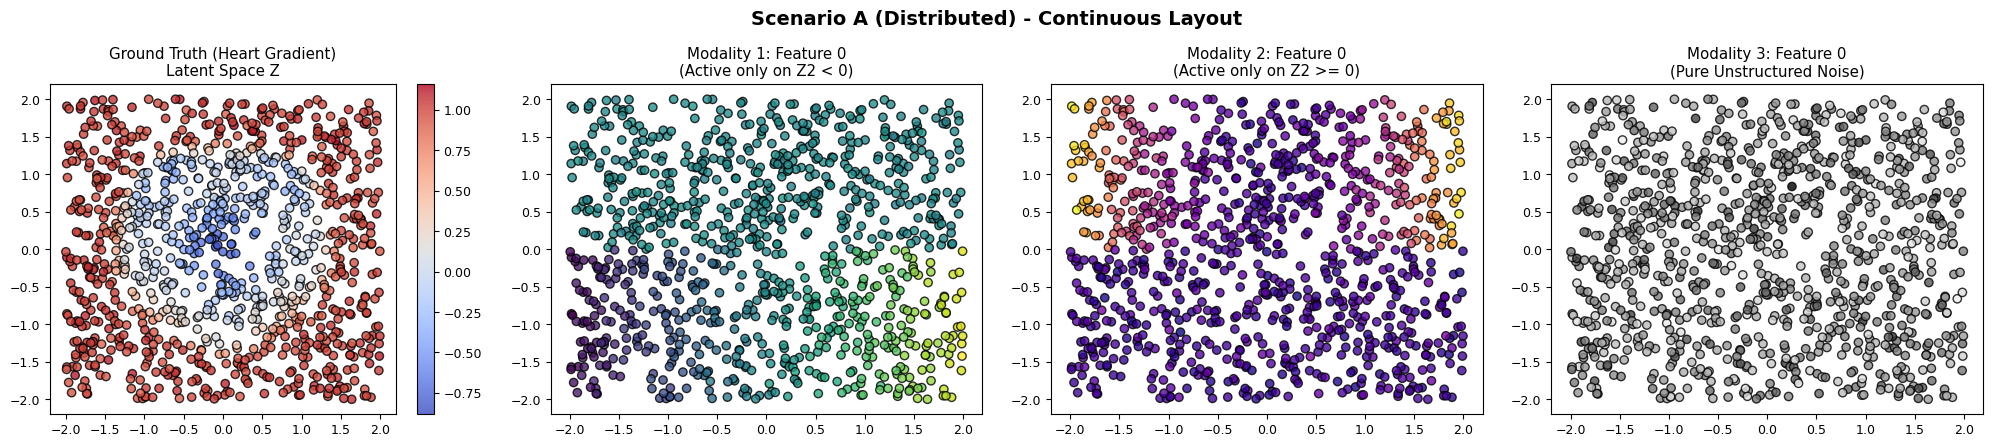

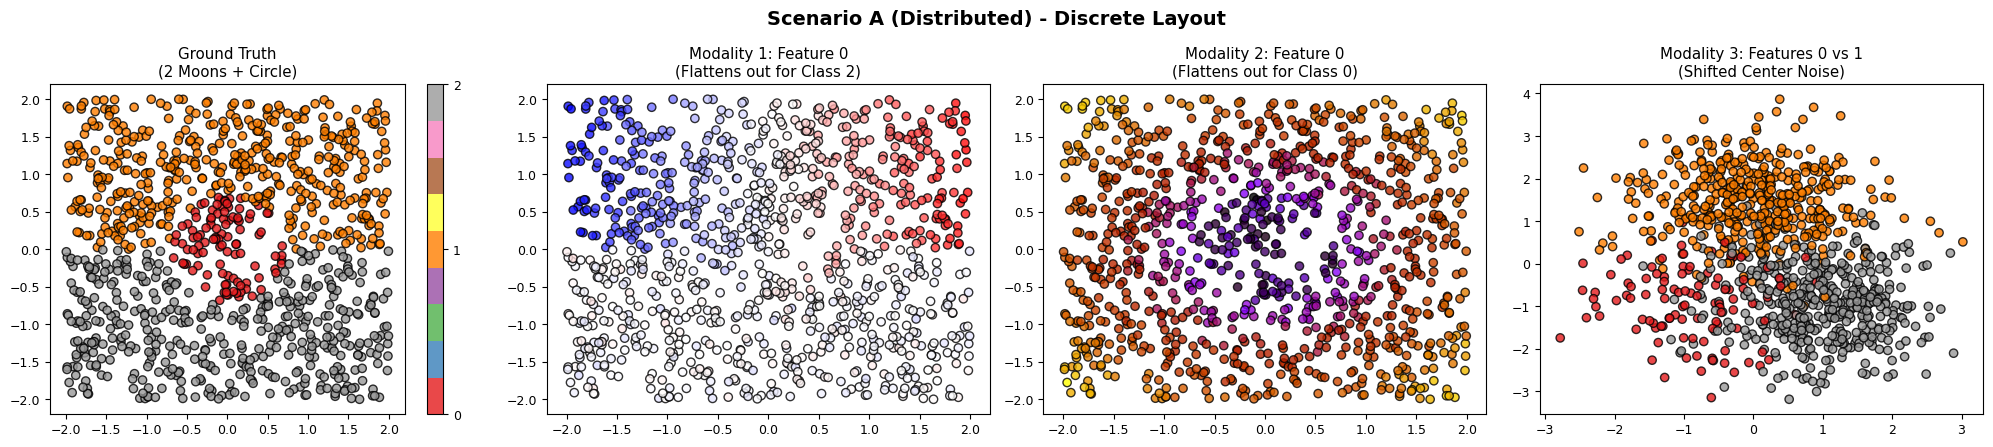

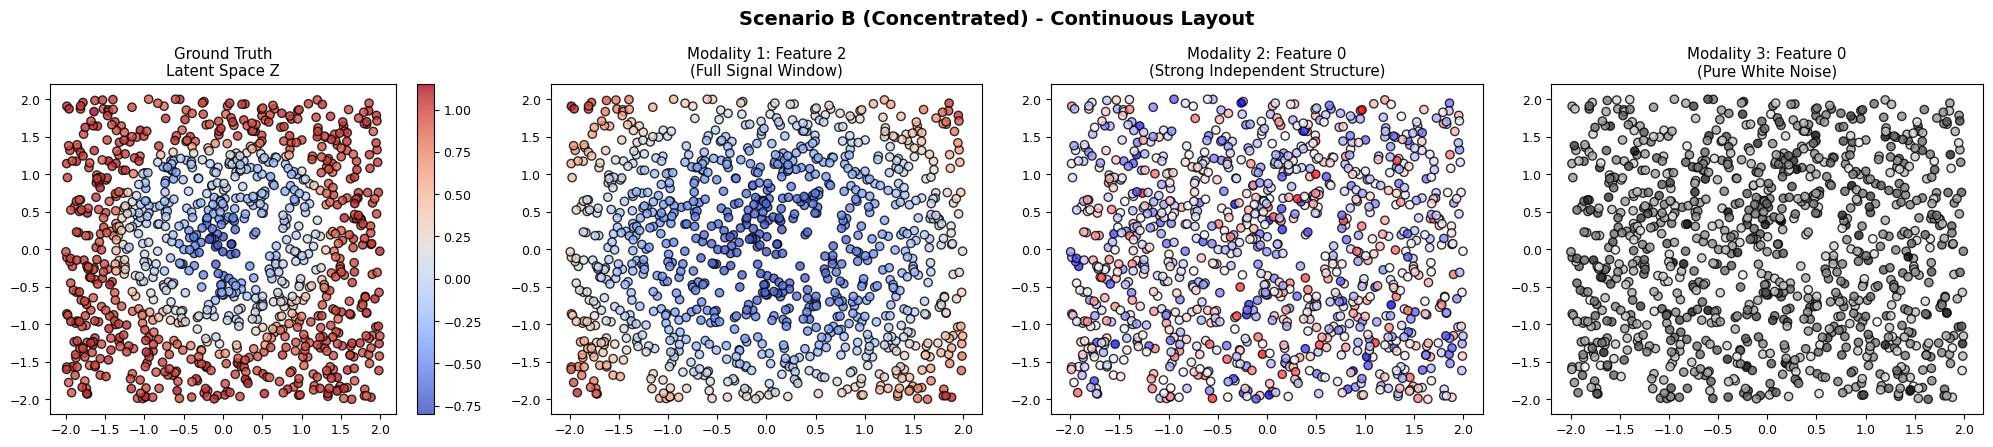

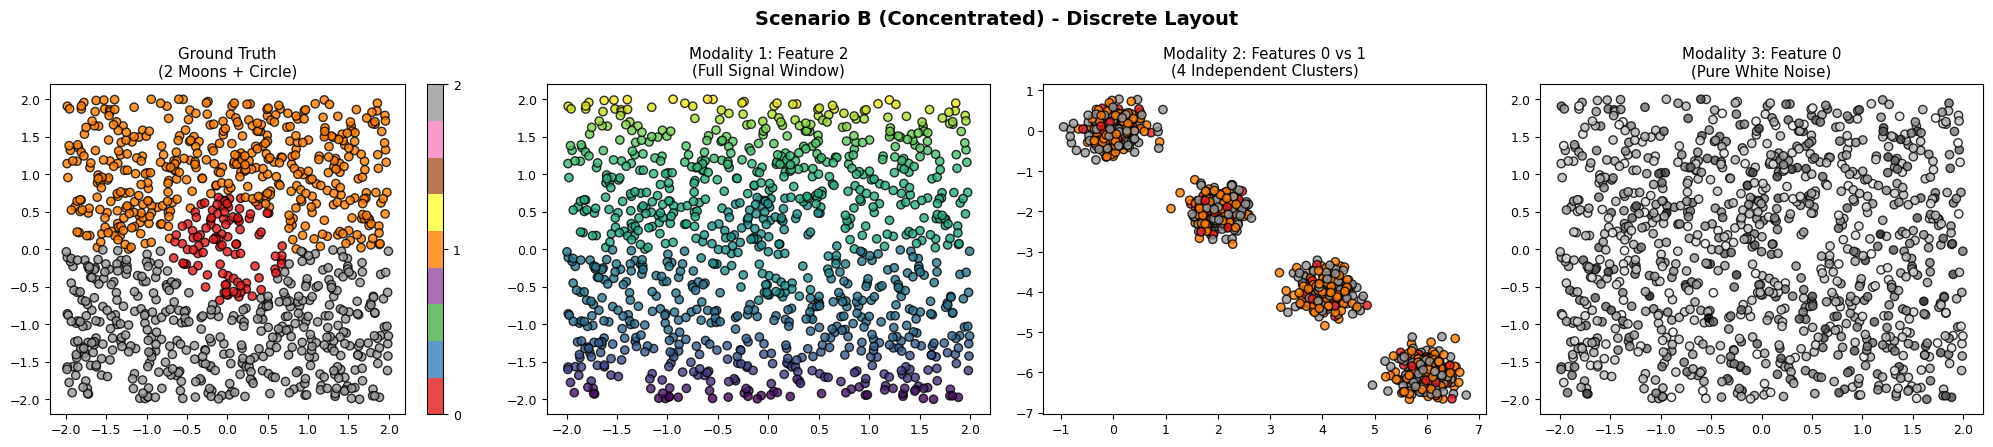

In [3]:
# params
## plot configuration
plt.rcParams.update({'font.size': 9, 'axes.labelsize': 10})


# scenario A
## case: continuous dataset
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
fig.suptitle("Scenario A (Distributed) - Continuous Layout", fontsize=14, fontweight='bold')

### labels
sc0 = axes[0].scatter(Z[:, 0], Z[:, 1], c=y_a_cont, cmap='coolwarm', edgecolor='k', alpha=0.8)
axes[0].set_title("Ground Truth (Heart Gradient)\nLatent Space Z")
fig.colorbar(sc0, ax=axes[0])

### modalities
#### modality 1 ....
axes[1].scatter(Z[:, 0], Z[:, 1], c=mod1_a_cont[:, 0], cmap='viridis', edgecolor='k', alpha=0.8)
axes[1].set_title("Modality 1: Feature 0\n(Active only on Z2 < 0)")

#### modality 2 ....
axes[2].scatter(Z[:, 0], Z[:, 1], c=mod2_a_cont[:, 0], cmap='plasma', edgecolor='k', alpha=0.8)
axes[2].set_title("Modality 2: Feature 0\n(Active only on Z2 >= 0)")

#### modality 3 ....
axes[3].scatter(Z[:, 0], Z[:, 1], c=mod3_a_cont[:, 0], cmap='Greys', edgecolor='k', alpha=0.8)
axes[3].set_title("Modality 3: Feature 0\n(Pure Unstructured Noise)")
plt.tight_layout()
plt.show()


## case: discrete dataset
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
fig.suptitle("Scenario A (Distributed) - Discrete Layout", fontsize=14, fontweight='bold')

### labels
sc1 = axes[0].scatter(Z[:, 0], Z[:, 1], c=y_a_disc, cmap='Set1', edgecolor='k', alpha=0.8)
axes[0].set_title("Ground Truth\n(2 Moons + Circle)")
fig.colorbar(sc1, ax=axes[0], ticks=[0, 1, 2])

### modalities
#### modality 1 ....
axes[1].scatter(Z[:, 0], Z[:, 1], c=mod1_a_disc[:, 0], cmap='bwr', edgecolor='k', alpha=0.8)
axes[1].set_title("Modality 1: Feature 0\n(Flattens out for Class 2)")

#### modality 2 ....
axes[2].scatter(Z[:, 0], Z[:, 1], c=mod2_a_disc[:, 0], cmap='gnuplot', edgecolor='k', alpha=0.8)
axes[2].set_title("Modality 2: Feature 0\n(Flattens out for Class 0)")

#### modality 3 ....
axes[3].scatter(mod3_a_disc[:, 0], mod3_a_disc[:, 1], c=y_a_disc, cmap='Set1', edgecolor='k', alpha=0.8)
axes[3].set_title("Modality 3: Features 0 vs 1\n(Shifted Center Noise)")
plt.tight_layout()
plt.show()


# scenario B
## case: continuous dataset
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
fig.suptitle("Scenario B (Concentrated) - Continuous Layout", fontsize=14, fontweight='bold')

### labels
sc2 = axes[0].scatter(Z[:, 0], Z[:, 1], c=y_b_cont, cmap='coolwarm', edgecolor='k', alpha=0.8)
axes[0].set_title("Ground Truth\nLatent Space Z")
fig.colorbar(sc2, ax=axes[0])

### modalities
#### modality 1 ....
axes[1].scatter(Z[:, 0], Z[:, 1], c=mod1_b_cont[:, 2], cmap='coolwarm', edgecolor='k', alpha=0.8)
axes[1].set_title("Modality 1: Feature 2\n(Full Signal Window)")

#### modality 2 ....
axes[2].scatter(Z[:, 0], Z[:, 1], c=mod2_b_cont[:, 0], cmap='bwr', edgecolor='k', alpha=0.8)
axes[2].set_title("Modality 2: Feature 0\n(Strong Independent Structure)")

#### modality 3 ....
axes[3].scatter(Z[:, 0], Z[:, 1], c=mod3_b_cont[:, 0], cmap='Greys', edgecolor='k', alpha=0.8)
axes[3].set_title("Modality 3: Feature 0\n(Pure White Noise)")
plt.tight_layout()
plt.show()


## case: discrete dataset
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
fig.suptitle("Scenario B (Concentrated) - Discrete Layout", fontsize=14, fontweight='bold')

### labels
sc3 = axes[0].scatter(Z[:, 0], Z[:, 1], c=y_b_disc, cmap='Set1', edgecolor='k', alpha=0.8)
axes[0].set_title("Ground Truth\n(2 Moons + Circle)")
fig.colorbar(sc3, ax=axes[0], ticks=[0, 1, 2])

### modalities
#### modality 1 ....
axes[1].scatter(Z[:, 0], Z[:, 1], c=mod1_b_disc[:, 2], cmap='viridis', edgecolor='k', alpha=0.8)
axes[1].set_title("Modality 1: Feature 2\n(Full Signal Window)")

#### modality 2 ....
axes[2].scatter(mod2_b_disc[:, 0], mod2_b_disc[:, 1], c=y_b_disc, cmap='Set1', edgecolor='k', alpha=0.8)
axes[2].set_title("Modality 2: Features 0 vs 1\n(4 Independent Clusters)")

#### modality 3 ....
axes[3].scatter(Z[:, 0], Z[:, 1], c=mod3_b_disc[:, 0], cmap='Greys', edgecolor='k', alpha=0.8)
axes[3].set_title("Modality 3: Feature 0\n(Pure White Noise)")
plt.tight_layout()
plt.show()

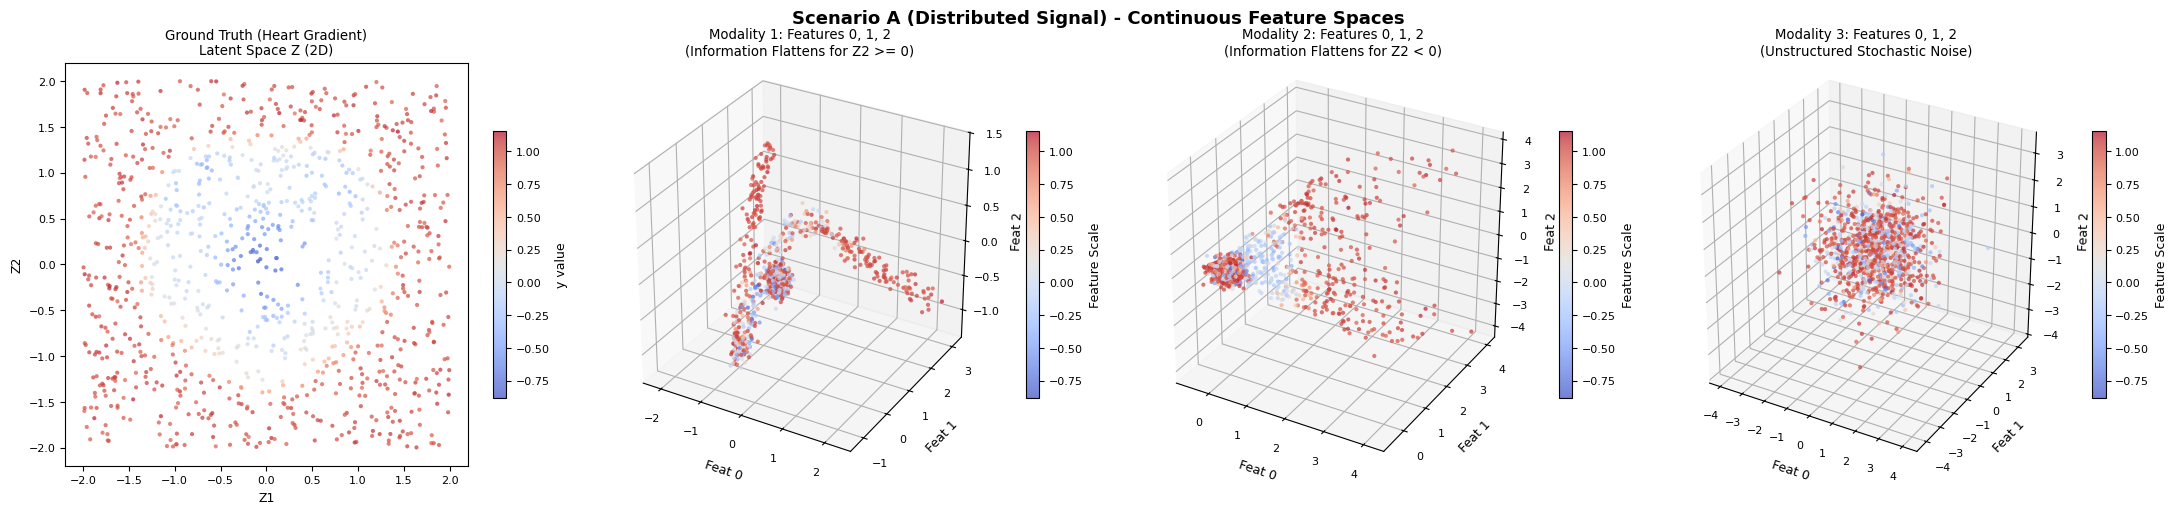

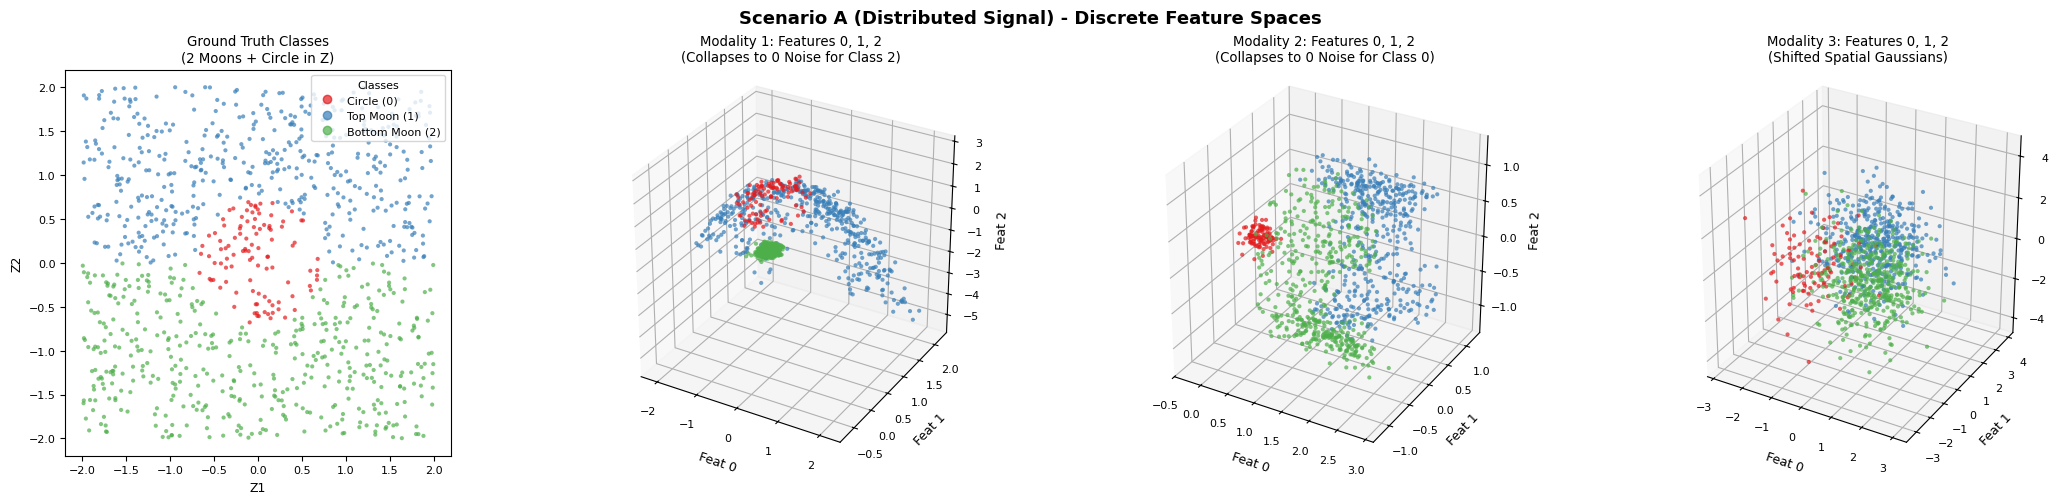

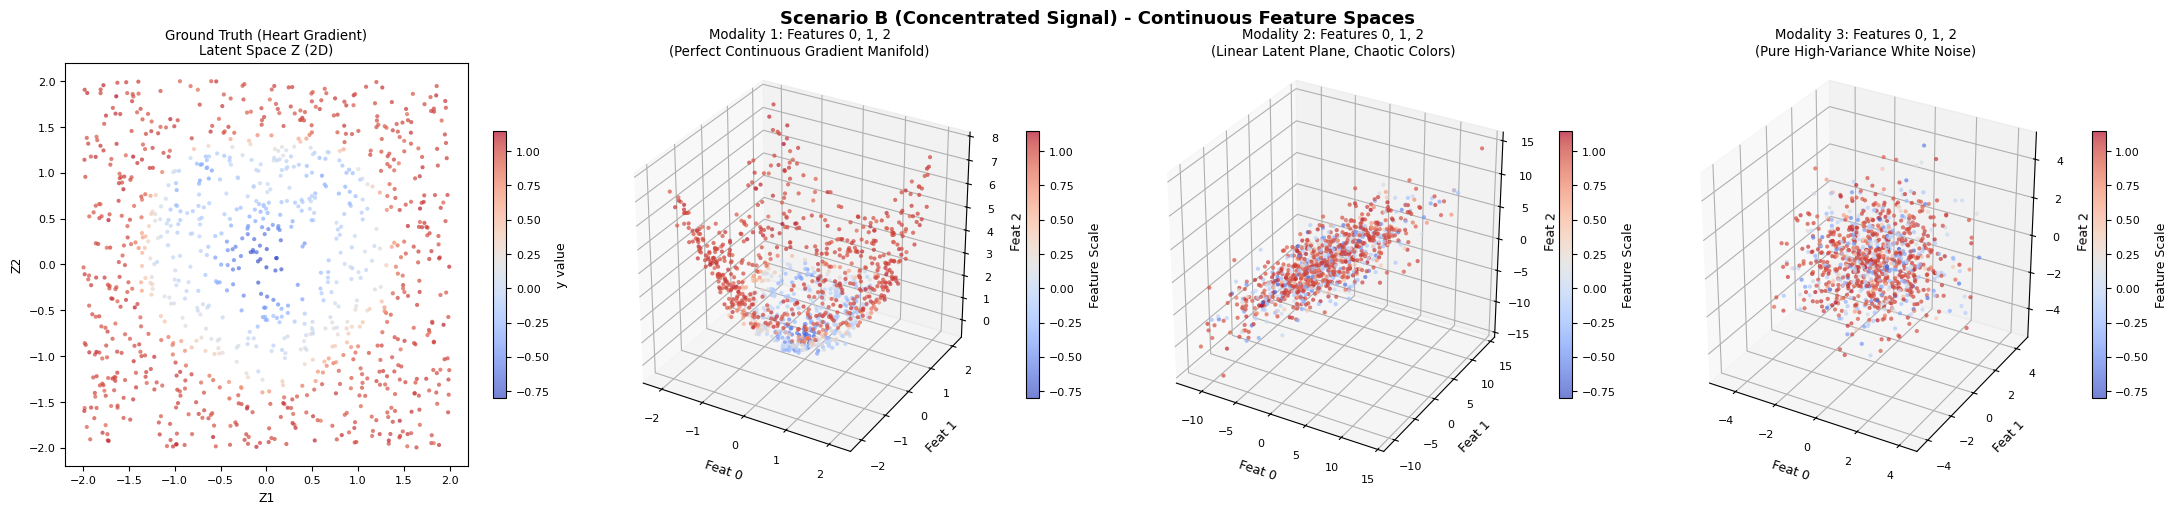

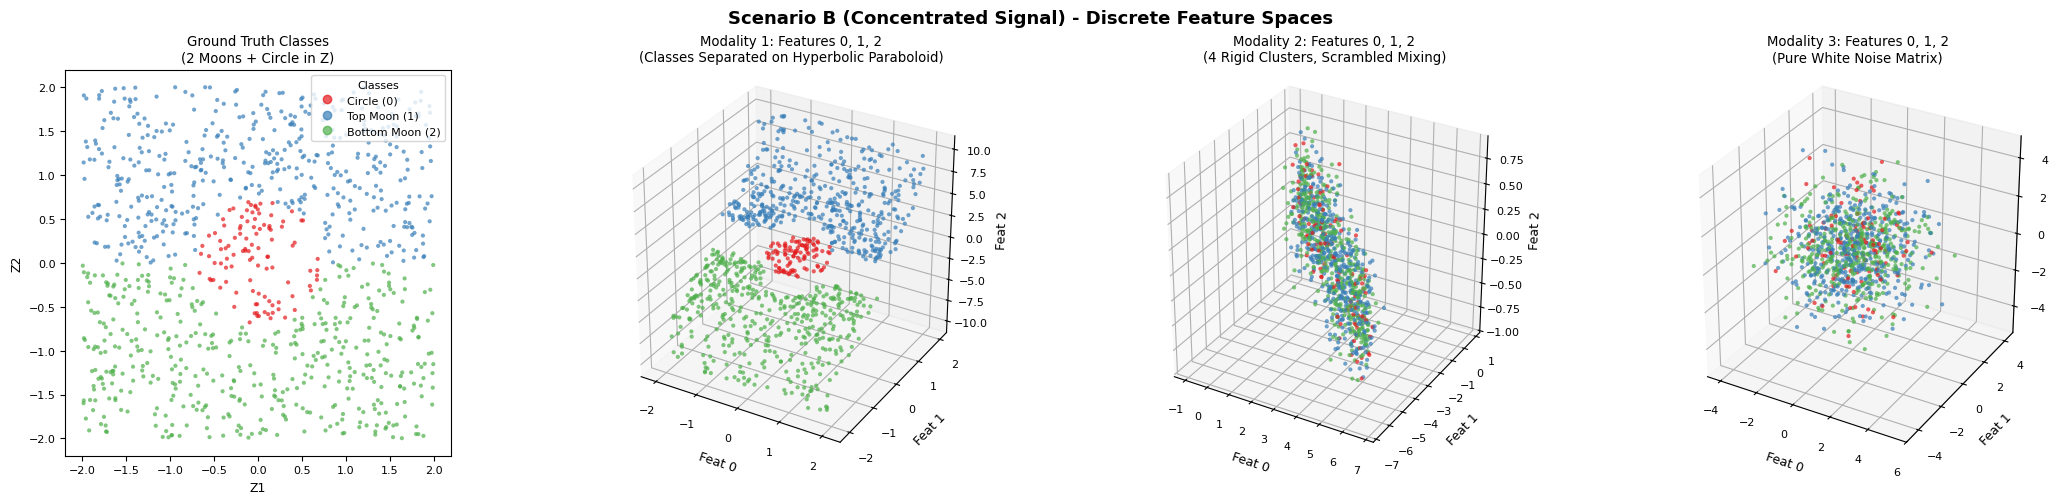

In [4]:
# # params
# ## subset fraction
# frac = 0.5
# size = n_samples if n_samples < 1000 else int(n_samples * frac)
# dot size
dot_transparency = 0.7
dot_size = 9 


# plotting section
## plot configuration
plt.rcParams.update({'font.size': 8, 'axes.labelsize': 9, 'figure.titlesize': 13})
discrete_colors = ['#e41a1c', '#377eb8', '#4daf4a']
discrete_cmap = ListedColormap(discrete_colors)


# scenario A
## case: continuous dataset
fig = plt.figure(figsize=(22, 5))
plt.suptitle("Scenario A (Distributed Signal) - Continuous Feature Spaces", fontweight='bold', y=0.98)

### labels
ax0 = fig.add_subplot(1, 4, 1)
sc0 = ax0.scatter(Z[:, 0], Z[:, 1], c=y_a_cont, cmap='coolwarm', edgecolor='none', alpha=dot_transparency, s=dot_size)
ax0.set_title("Ground Truth (Heart Gradient)\nLatent Space Z (2D)")
ax0.set_xlabel("Z1")
ax0.set_ylabel("Z2")
ax0.set_aspect('equal')
fig.colorbar(sc0, ax=ax0, label="y value", shrink=0.6)

### modalities
#### modality 1 ....
ax1 = fig.add_subplot(1, 4, 2, projection='3d')
sc1 = ax1.scatter(mod1_a_cont[:, 0], mod1_a_cont[:, 1], mod1_a_cont[:, 2], c=y_a_cont, cmap='coolwarm', edgecolor='none', alpha=dot_transparency, s=dot_size)
ax1.set_title("Modality 1: Features 0, 1, 2\n(Information Flattens for Z2 >= 0)")
ax1.set_xlabel("Feat 0")
ax1.set_ylabel("Feat 1")
ax1.set_zlabel("Feat 2")
ax1.set_box_aspect((1,1,1))
fig.colorbar(sc1, ax=ax1, label="Feature Scale", shrink=0.6)

#### modality 2 ....
ax2 = fig.add_subplot(1, 4, 3, projection='3d')
sc2 = ax2.scatter(mod2_a_cont[:, 0], mod2_a_cont[:, 1], mod2_a_cont[:, 2], c=y_a_cont, cmap='coolwarm', edgecolor='none', alpha=dot_transparency, s=dot_size)
ax2.set_title("Modality 2: Features 0, 1, 2\n(Information Flattens for Z2 < 0)")
ax2.set_xlabel("Feat 0")
ax2.set_ylabel("Feat 1")
ax2.set_zlabel("Feat 2")
ax2.set_box_aspect((1,1,1))
fig.colorbar(sc2, ax=ax2, label="Feature Scale", shrink=0.6)

#### modality 3 ....
ax3 = fig.add_subplot(1, 4, 4, projection='3d')
sc3 = ax3.scatter(mod3_a_cont[:, 0], mod3_a_cont[:, 1], mod3_a_cont[:, 2], c=y_a_cont, cmap='coolwarm', edgecolor='none', alpha=dot_transparency, s=dot_size)
ax3.set_title("Modality 3: Features 0, 1, 2\n(Unstructured Stochastic Noise)")
ax3.set_xlabel("Feat 0")
ax3.set_ylabel("Feat 1")
ax3.set_zlabel("Feat 2")
ax3.set_box_aspect((1,1,1))
fig.colorbar(sc3, ax=ax3, label="Feature Scale", shrink=0.6)
plt.tight_layout()
plt.show()


## case: discrete dataset
fig = plt.figure(figsize=(22, 5))
plt.suptitle("Scenario A (Distributed Signal) - Discrete Feature Spaces", fontweight='bold', y=0.98)

### labels
ax0 = fig.add_subplot(1, 4, 1)
sc0 = ax0.scatter(Z[:, 0], Z[:, 1], c=y_a_disc, cmap=discrete_cmap, edgecolor='none', alpha=dot_transparency, s=dot_size)
ax0.set_title("Ground Truth Classes\n(2 Moons + Circle in Z)")
ax0.set_xlabel("Z1")
ax0.set_ylabel("Z2")
ax0.set_aspect('equal')
handles, _ = sc0.legend_elements()
ax0.legend(handles, ['Circle (0)', 'Top Moon (1)', 'Bottom Moon (2)'], title="Classes", loc='upper right')

### modalities
#### modality 1 ....
ax1 = fig.add_subplot(1, 4, 2, projection='3d')
ax1.scatter(mod1_a_disc[:, 0], mod1_a_disc[:, 1], mod1_a_disc[:, 2], c=y_a_disc, cmap=discrete_cmap, edgecolor='none', alpha=dot_transparency, s=dot_size)
ax1.set_title("Modality 1: Features 0, 1, 2\n(Collapses to 0 Noise for Class 2)")
ax1.set_xlabel("Feat 0")
ax1.set_ylabel("Feat 1")
ax1.set_zlabel("Feat 2")
ax1.set_box_aspect((1,1,1))

#### modality 2 ....
ax2 = fig.add_subplot(1, 4, 3, projection='3d')
ax2.scatter(mod2_a_disc[:, 0], mod2_a_disc[:, 1], mod2_a_disc[:, 2], c=y_a_disc, cmap=discrete_cmap, edgecolor='none', alpha=dot_transparency, s=dot_size)
ax2.set_title("Modality 2: Features 0, 1, 2\n(Collapses to 0 Noise for Class 0)")
ax2.set_xlabel("Feat 0")
ax2.set_ylabel("Feat 1")
ax2.set_zlabel("Feat 2")
ax2.set_box_aspect((1,1,1))

#### modality 3 ....
ax3 = fig.add_subplot(1, 4, 4, projection='3d')
ax3.scatter(mod3_a_disc[:, 0], mod3_a_disc[:, 1], mod3_a_disc[:, 2], c=y_a_disc, cmap=discrete_cmap, edgecolor='none', alpha=dot_transparency, s=dot_size)
ax3.set_title("Modality 3: Features 0, 1, 2\n(Shifted Spatial Gaussians)")
ax3.set_xlabel("Feat 0")
ax3.set_ylabel("Feat 1")
ax3.set_zlabel("Feat 2")
ax3.set_box_aspect((1,1,1))
plt.tight_layout()
plt.show()


# scenario B
## case: continuous dataset
fig = plt.figure(figsize=(22, 5))
plt.suptitle("Scenario B (Concentrated Signal) - Continuous Feature Spaces", fontweight='bold', y=0.98)

### labels
ax0 = fig.add_subplot(1, 4, 1)
sc0 = ax0.scatter(Z[:, 0], Z[:, 1], c=y_b_cont, cmap='coolwarm', edgecolor='none', alpha=dot_transparency, s=dot_size)
ax0.set_title("Ground Truth (Heart Gradient)\nLatent Space Z (2D)")
ax0.set_xlabel("Z1")
ax0.set_ylabel("Z2")
ax0.set_aspect('equal')
fig.colorbar(sc0, ax=ax0, label="y value", shrink=0.6)

### modalities
#### modality 1 ....
ax1 = fig.add_subplot(1, 4, 2, projection='3d')
sc1 = ax1.scatter(mod1_b_cont[:, 0], mod1_b_cont[:, 1], mod1_b_cont[:, 2], c=y_b_cont, cmap='coolwarm', edgecolor='none', alpha=dot_transparency, s=dot_size)
ax1.set_title("Modality 1: Features 0, 1, 2\n(Perfect Continuous Gradient Manifold)")
ax1.set_xlabel("Feat 0")
ax1.set_ylabel("Feat 1")
ax1.set_zlabel("Feat 2")
ax1.set_box_aspect((1,1,1))
fig.colorbar(sc1, ax=ax1, label="Feature Scale", shrink=0.6)

#### modality 2 ....
ax2 = fig.add_subplot(1, 4, 3, projection='3d')
sc2 = ax2.scatter(mod2_b_cont[:, 0], mod2_b_cont[:, 1], mod2_b_cont[:, 2], c=y_b_cont, cmap='coolwarm', edgecolor='none', alpha=dot_transparency, s=dot_size)
ax2.set_title("Modality 2: Features 0, 1, 2\n(Linear Latent Plane, Chaotic Colors)")
ax2.set_xlabel("Feat 0")
ax2.set_ylabel("Feat 1")
ax2.set_zlabel("Feat 2")
ax2.set_box_aspect((1,1,1))
fig.colorbar(sc2, ax=ax2, label="Feature Scale", shrink=0.6)

#### modality 3 ....
ax3 = fig.add_subplot(1, 4, 4, projection='3d')
sc3 = ax3.scatter(mod3_b_cont[:, 0], mod3_b_cont[:, 1], mod3_b_cont[:, 2], c=y_b_cont, cmap='coolwarm', edgecolor='none', alpha=dot_transparency, s=dot_size)
ax3.set_title("Modality 3: Features 0, 1, 2\n(Pure High-Variance White Noise)")
ax3.set_xlabel("Feat 0")
ax3.set_ylabel("Feat 1")
ax3.set_zlabel("Feat 2")
ax3.set_box_aspect((1,1,1))
fig.colorbar(sc3, ax=ax3, label="Feature Scale", shrink=0.6)
plt.tight_layout()
plt.show()


## case: discrete dataset
fig = plt.figure(figsize=(22, 5))
plt.suptitle("Scenario B (Concentrated Signal) - Discrete Feature Spaces", fontweight='bold', y=0.98)

### labels
ax0 = fig.add_subplot(1, 4, 1)
sc0 = ax0.scatter(Z[:, 0], Z[:, 1], c=y_b_disc, cmap=discrete_cmap, edgecolor='none', alpha=dot_transparency, s=dot_size)
ax0.set_title("Ground Truth Classes\n(2 Moons + Circle in Z)")
ax0.set_xlabel("Z1")
ax0.set_ylabel("Z2")
ax0.set_aspect('equal')
ax0.legend(handles, ['Circle (0)', 'Top Moon (1)', 'Bottom Moon (2)'], title="Classes", loc='upper right')

### modalities
#### modality 1 ....
ax1 = fig.add_subplot(1, 4, 2, projection='3d')
ax1.scatter(mod1_b_disc[:, 0], mod1_b_disc[:, 1], mod1_b_disc[:, 2], c=y_b_disc, cmap=discrete_cmap, edgecolor='none', alpha=dot_transparency, s=dot_size)
ax1.set_title("Modality 1: Features 0, 1, 2\n(Classes Separated on Hyperbolic Paraboloid)")
ax1.set_xlabel("Feat 0")
ax1.set_ylabel("Feat 1")
ax1.set_zlabel("Feat 2")
ax1.set_box_aspect((1,1,1))

#### modality 2 ....
ax2 = fig.add_subplot(1, 4, 3, projection='3d')
ax2.scatter(mod2_b_disc[:, 0], mod2_b_disc[:, 1], mod2_b_disc[:, 2], c=y_b_disc, cmap=discrete_cmap, edgecolor='none', alpha=dot_transparency, s=dot_size)
ax2.set_title("Modality 2: Features 0, 1, 2\n(4 Rigid Clusters, Scrambled Mixing)")
ax2.set_xlabel("Feat 0")
ax2.set_ylabel("Feat 1")
ax2.set_zlabel("Feat 2")
ax2.set_box_aspect((1,1,1))

#### modality 3 ....
ax3 = fig.add_subplot(1, 4, 4, projection='3d')
ax3.scatter(mod3_b_disc[:, 0], mod3_b_disc[:, 1], mod3_b_disc[:, 2], c=y_b_disc, cmap=discrete_cmap, edgecolor='none', alpha=dot_transparency, s=dot_size)
ax3.set_title("Modality 3: Features 0, 1, 2\n(Pure White Noise Matrix)")
ax3.set_xlabel("Feat 0")
ax3.set_ylabel("Feat 1")
ax3.set_zlabel("Feat 2")
ax3.set_box_aspect((1,1,1))
plt.tight_layout()
plt.show()

In [5]:
# ## dot size and transparency for consistent plotting
# dot_transparency = 0.7
# dot_size = 9 

# ## model configurations
# test_size = 0.25
# n_comp_pca = 2
# n_factors_mofa = 3
# discrete_colors = ['#e41a1c', '#377eb8', '#4daf4a']
# discrete_cmap = ListedColormap(discrete_colors)

# # evaluation helper function
# ## downstream modeling pipeline
# ## switching to a non-linear downstream evaluator for continuous tracks
# def evaluate_embeddings(X_embeddings, y, is_discrete):
#     if is_discrete:
#         X_train, X_test, y_train, y_test = train_test_split(
#             X_embeddings, y, test_size=test_size, random_state=seed, stratify=y
#         )
#         # Clean logistic regression auto-detecting multi-class formats
#         clf = LogisticRegression(max_iter=1000, random_state=seed)
#         clf.fit(X_train, y_train)
#         preds = clf.predict(X_test)
#         return accuracy_score(y_test, preds)
#     else:
#         X_train, X_test, y_train, y_test = train_test_split(
#             X_embeddings, y, test_size=test_size, random_state=seed
#         )
#         # Using K-NN Regressor to accurately map non-linear geometric manifolds without requiring linearity
#         reg = KNeighborsRegressor(n_neighbors=5, weights='distance')
#         reg.fit(X_train, y_train)
#         preds = reg.predict(X_test)
#         return r2_score(y_test, preds)


# # execution and plotting helper function
# ## analytical factory for embedding generation and visualization
# def run_full_analysis(m1, m2, m3, y, scenario_title, is_discrete):
#     # PCA section
#     pca_obj_m1 = PCA(n_components=n_comp_pca, random_state=seed)
#     pca_m1 = pca_obj_m1.fit_transform(m1)
    
#     pca_obj_m2 = PCA(n_components=n_comp_pca, random_state=seed)
#     pca_m2 = pca_obj_m2.fit_transform(m2)
    
#     pca_obj_m3 = PCA(n_components=n_comp_pca, random_state=seed)
#     pca_m3 = pca_obj_m3.fit_transform(m3)
    
#     concat_data = np.hstack([m1, m2, m3])
#     pca_obj_concat = PCA(n_components=n_comp_pca, random_state=seed)
#     pca_concat = pca_obj_concat.fit_transform(concat_data)
    
#     # MOFA section
#     mofa_kwargs = {"n_factors": n_factors_mofa, "seed": seed, "quiet": True}

#     import sys 
#     old_stdout = sys.stdout
#     sys.stdout = open(os.devnull, 'w')
#     try:
#         mdata_m1 = mu.MuData({"mod1": sc.AnnData(m1)})
#         mu.tl.mofa(mdata_m1, **mofa_kwargs)
#         mofa_m1 = mdata_m1.obsm["X_mofa"]
        
#         mdata_m2 = mu.MuData({"mod2": sc.AnnData(m2)})
#         mu.tl.mofa(mdata_m2, **mofa_kwargs)
#         mofa_m2 = mdata_m2.obsm["X_mofa"]
        
#         mdata_m3 = mu.MuData({"mod3": sc.AnnData(m3)})
#         mu.tl.mofa(mdata_m3, **mofa_kwargs)
#         mofa_m3 = mdata_m3.obsm["X_mofa"]
        
#         mdata_shared = mu.MuData({"mod1": sc.AnnData(m1), "mod2": sc.AnnData(m2), "mod3": sc.AnnData(m3)})
#         mu.tl.mofa(mdata_shared, **mofa_kwargs)
#         mofa_shared = mdata_shared.obsm["X_mofa"]
#     finally:
#         sys.stdout.close()
#         sys.stdout = old_stdout
    
#     # Downstream evaluation mapping
#     embeddings = {
#         "PCA: Modality 1": pca_m1, "PCA: Modality 2": pca_m2, "PCA: Modality 3": pca_m3, "PCA: Concatenated": pca_concat,
#         "MOFA: Modality 1": mofa_m1, "MOFA: Modality 2": mofa_m2, "MOFA: Modality 3": mofa_m3, "MOFA: Shared Joint": mofa_shared
#     }
    
#     metric_name = 'Test Accuracy' if is_discrete else 'Test Non-linear R2 (KNN)'
#     results = {name: evaluate_embeddings(emb, y, is_discrete) for name, emb in embeddings.items()}
#     df_res = pd.DataFrame.from_dict(results, orient='index', columns=[metric_name])
    
#     # Use all samples for plotting
#     plot_idx = np.arange(n_samples)
#     cmap_to_use = discrete_cmap if is_discrete else 'coolwarm'
    
#     # Plotting row 1: PCA Embeddings
#     fig, axes = plt.subplots(1, 4, figsize=(22, 4.5))
#     fig.suptitle(f"{scenario_title} - PCA Dimensionality Reduction", fontweight='bold', fontsize=12)
#     pca_list = [pca_m1, pca_m2, pca_m3, pca_concat]
#     pca_objs = [pca_obj_m1, pca_obj_m2, pca_obj_m3, pca_obj_concat]
#     titles_pca = ["Modality 1", "Modality 2", "Modality 3", "Concatenated views"]
    
#     for idx, (emb, obj, title) in enumerate(zip(pca_list, pca_objs, titles_pca)):
#         scat = axes[idx].scatter(emb[plot_idx, 0], emb[plot_idx, 1], c=y[plot_idx], cmap=cmap_to_use, alpha=dot_transparency, s=dot_size, edgecolor='none')
#         axes[idx].set_title(title)
#         axes[idx].set_xlabel(f"PC1 ({obj.explained_variance_ratio_[0]*100:.1f}%)")
#         axes[idx].set_ylabel(f"PC2 ({obj.explained_variance_ratio_[1]*100:.1f}%)")
#         if not is_discrete:
#             fig.colorbar(scat, ax=axes[idx], shrink=0.6)
#         elif idx == 3:
#             handles, _ = scat.legend_elements()
#             axes[idx].legend(handles, ['Circle (0)', 'Top Moon (1)', 'Bottom Moon (2)'], title="Classes", loc='best')
#     plt.tight_layout()
#     plt.show()

#     # Plotting row 2: MOFA Embeddings
#     fig, axes = plt.subplots(1, 4, figsize=(22, 4.5))
#     fig.suptitle(f"{scenario_title} - MOFA Factor Embeddings", fontweight='bold', fontsize=12)
#     mofa_list = [mofa_m1, mofa_m2, mofa_m3, mofa_shared]
#     titles_mofa = ["Modality 1 Specific", "Modality 2 Specific", "Modality 3 Specific", "Shared Joint Spaces"]
    
#     for idx, (emb, title) in enumerate(zip(mofa_list, titles_mofa)):
#         scat = axes[idx].scatter(emb[plot_idx, 0], emb[plot_idx, 1], c=y[plot_idx], cmap=cmap_to_use, alpha=dot_transparency, s=dot_size, edgecolor='none')
#         axes[idx].set_title(title)
#         axes[idx].set_xlabel("Factor 1")
#         axes[idx].set_ylabel("Factor 2")
#         if not is_discrete:
#             fig.colorbar(scat, ax=axes[idx], shrink=0.6)
#         elif idx == 3:
#             handles, _ = scat.legend_elements()
#             axes[idx].legend(handles, ['Circle (0)', 'Top Moon (1)', 'Bottom Moon (2)'], title="Classes", loc='best')
#     plt.tight_layout()
#     plt.show()
    
#     print(f"\n--- {scenario_title} Downstream Performance Analysis Table ---")
#     print(df_res.to_markdown())
#     print("\n" + "="*80 + "\n")


# # execution calls
# ## running analytical pipelines for all four combinations
# run_full_analysis(mod1_a_cont, mod2_a_cont, mod3_a_cont, y_a_cont, "Scenario A (Distributed) - Continuous Matrix", is_discrete=False)
# run_full_analysis(mod1_a_disc, mod2_a_disc, mod3_a_disc, y_a_disc, "Scenario A (Distributed) - Discrete Matrix", is_discrete=True)
# run_full_analysis(mod1_b_cont, mod2_b_cont, mod3_b_cont, y_b_cont, "Scenario B (Concentrated) - Continuous Matrix", is_discrete=False)
# run_full_analysis(mod1_b_disc, mod2_b_disc, mod3_b_disc, y_b_disc, "Scenario B (Concentrated) - Discrete Matrix", is_discrete=True)

/home/maxi7524/micromamba/envs/bio_env/lib/python3.13/site-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/maxi7524/micromamba/envs/bio_env/lib/python3.13/site-packages/mudata/_core/mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


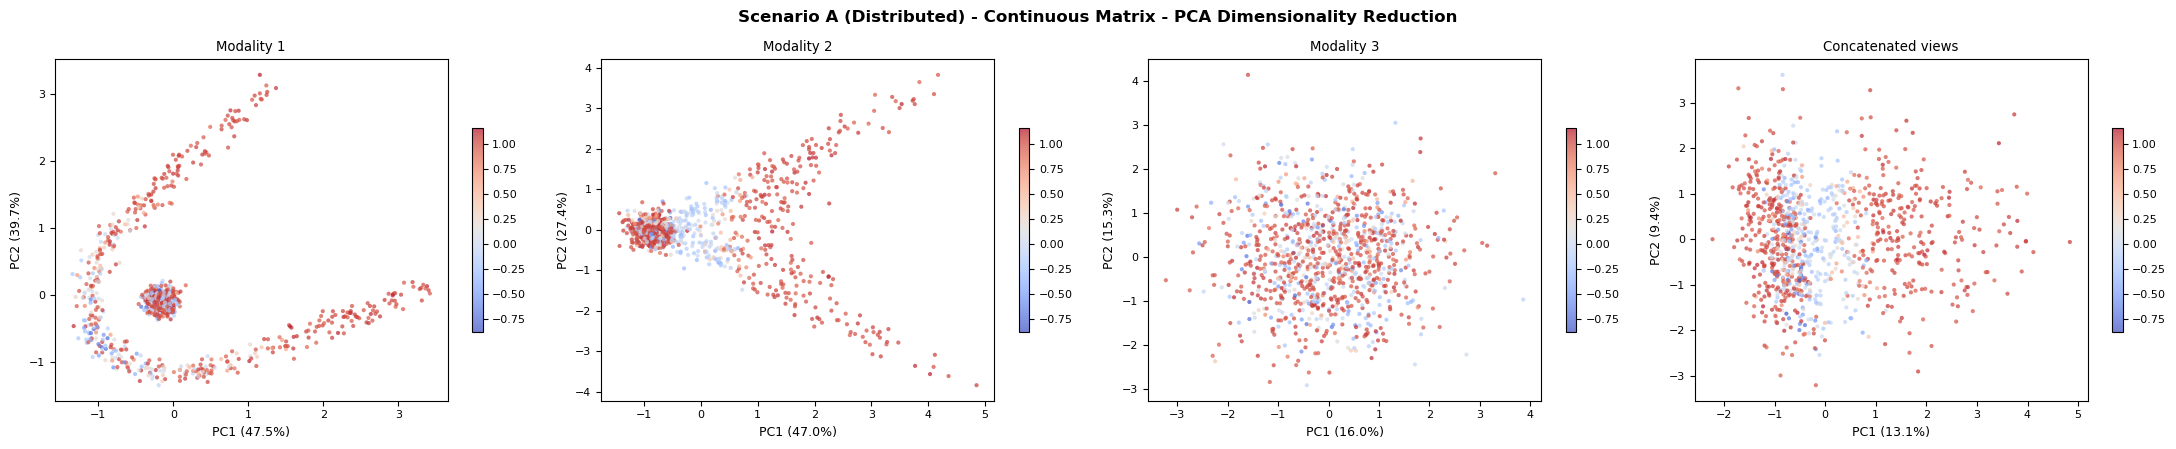

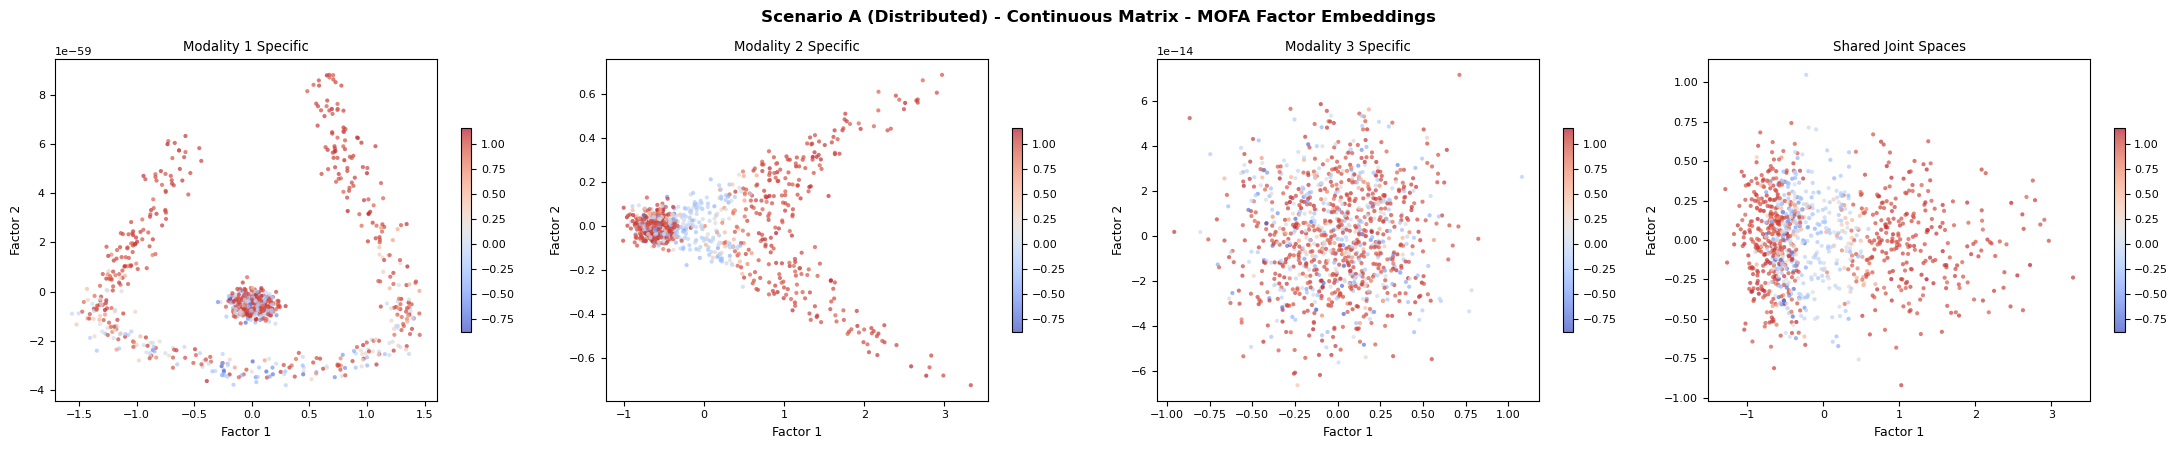


--- Scenario A (Distributed) - Continuous Matrix Downstream Performance Analysis Table ---
|                    |   Test Non-linear R2 (Random Forest) |
|:-------------------|-------------------------------------:|
| PCA: Modality 1    |                            0.0681438 |
| PCA: Modality 2    |                            0.242947  |
| PCA: Modality 3    |                           -0.118358  |
| PCA: Concatenated  |                            0.341197  |
| MOFA: Modality 1   |                           -0.0580808 |
| MOFA: Modality 2   |                            0.25385   |
| MOFA: Modality 3   |                           -0.160129  |
| MOFA: Shared Joint |                            0.425343  |




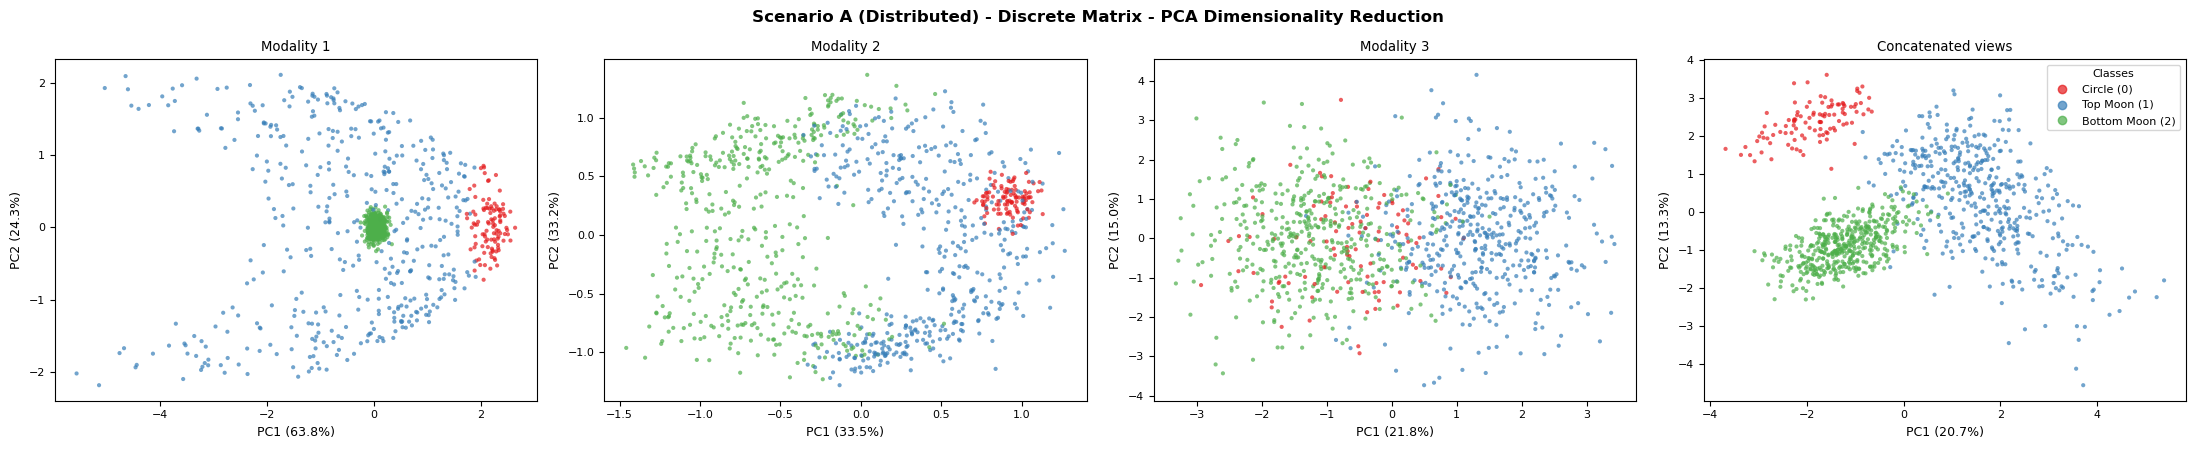

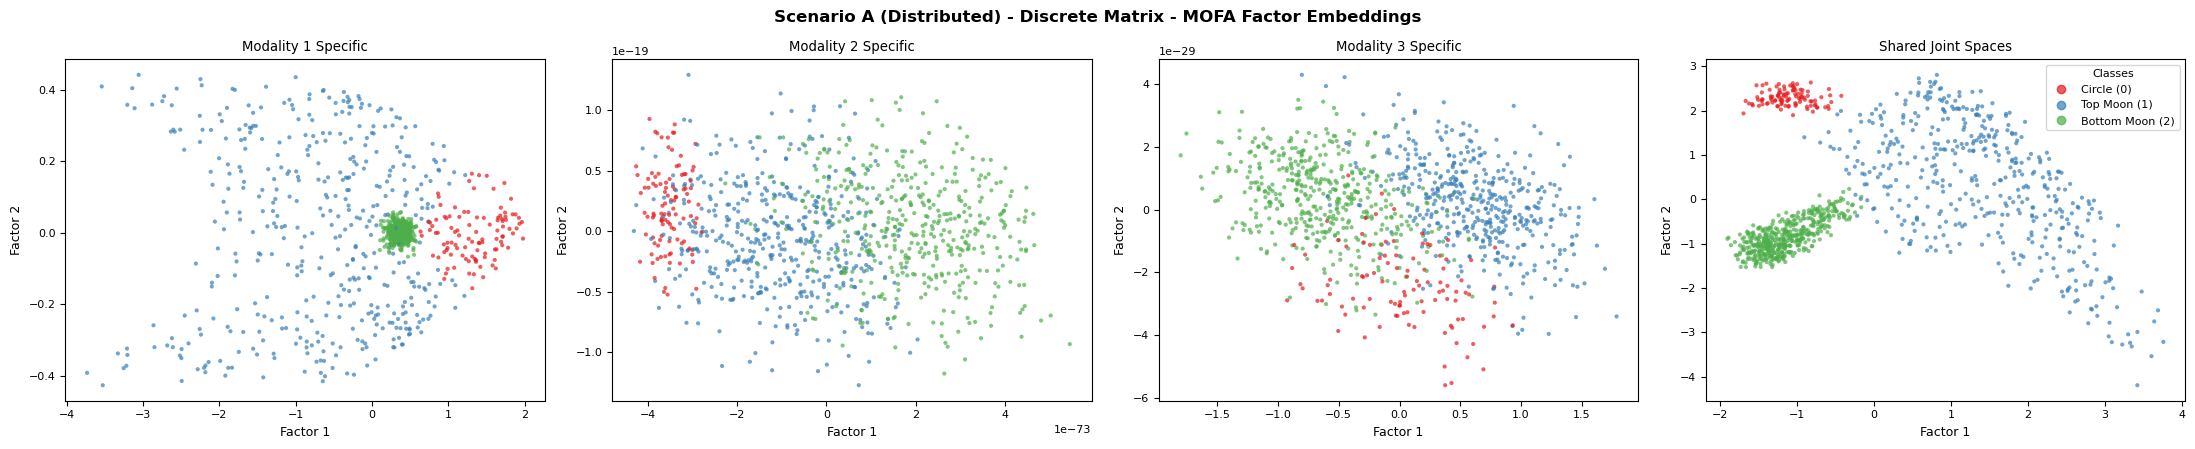


--- Scenario A (Distributed) - Discrete Matrix Downstream Performance Analysis Table ---
|                    |   Test Accuracy |
|:-------------------|----------------:|
| PCA: Modality 1    |           0.756 |
| PCA: Modality 2    |           0.836 |
| PCA: Modality 3    |           0.836 |
| PCA: Concatenated  |           0.972 |
| MOFA: Modality 1   |           0.852 |
| MOFA: Modality 2   |           0.448 |
| MOFA: Modality 3   |           0.824 |
| MOFA: Shared Joint |           0.992 |




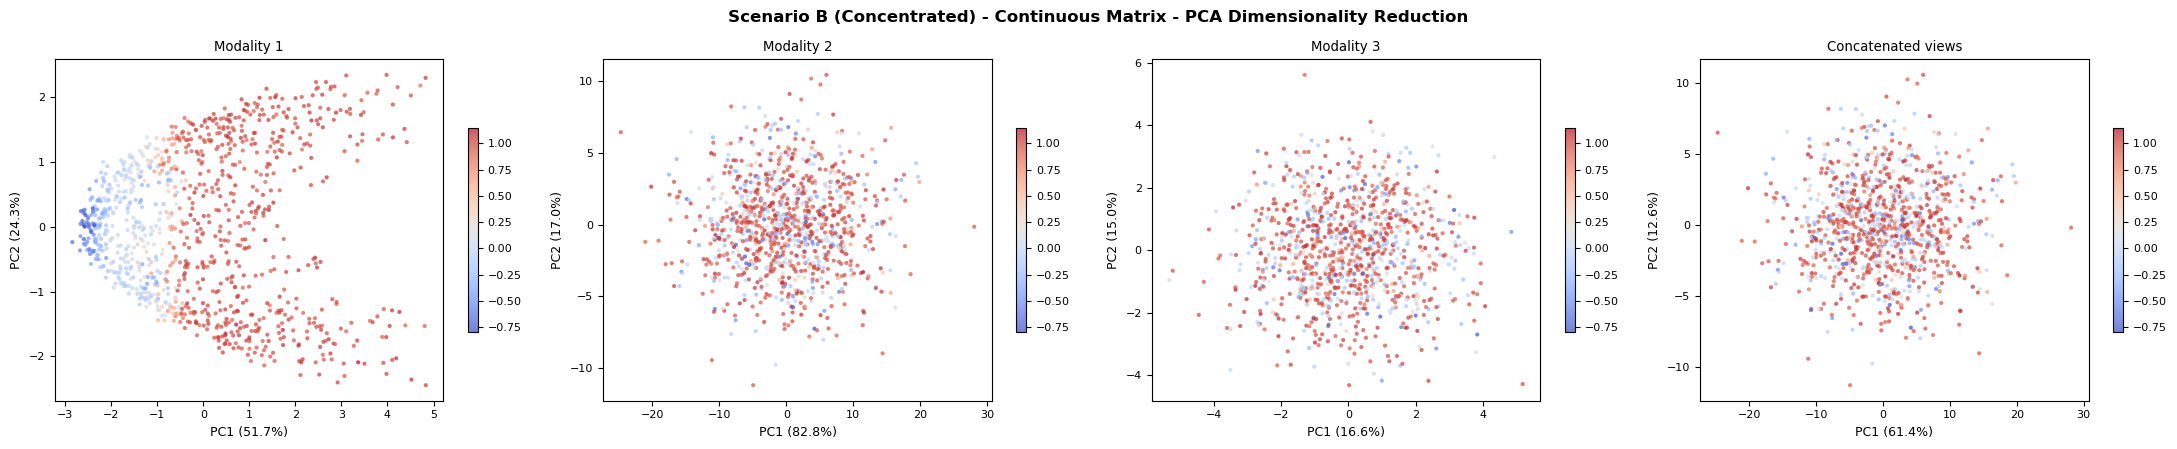

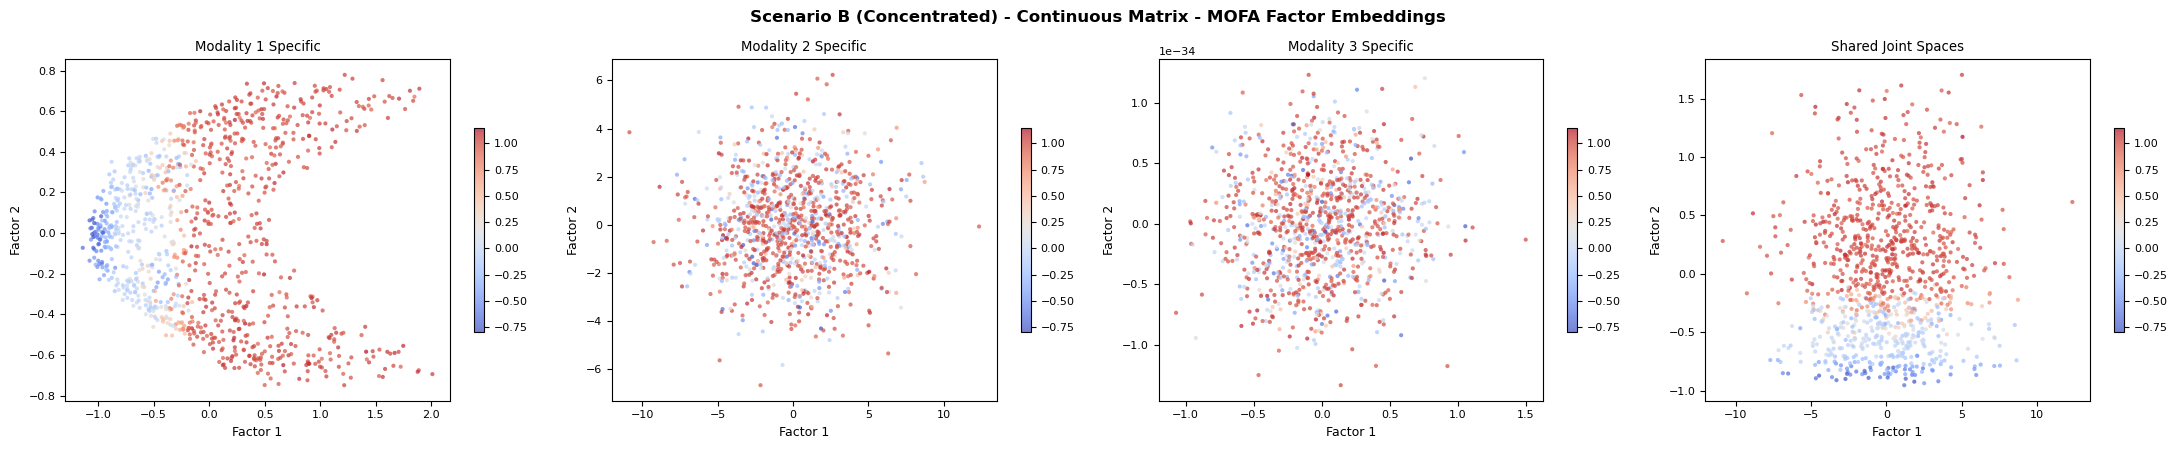


--- Scenario B (Concentrated) - Continuous Matrix Downstream Performance Analysis Table ---
|                    |   Test Non-linear R2 (Random Forest) |
|:-------------------|-------------------------------------:|
| PCA: Modality 1    |                            0.928183  |
| PCA: Modality 2    |                           -0.0793885 |
| PCA: Modality 3    |                           -0.022193  |
| PCA: Concatenated  |                           -0.0825756 |
| MOFA: Modality 1   |                            0.965758  |
| MOFA: Modality 2   |                           -0.080889  |
| MOFA: Modality 3   |                           -0.145758  |
| MOFA: Shared Joint |                            0.891221  |




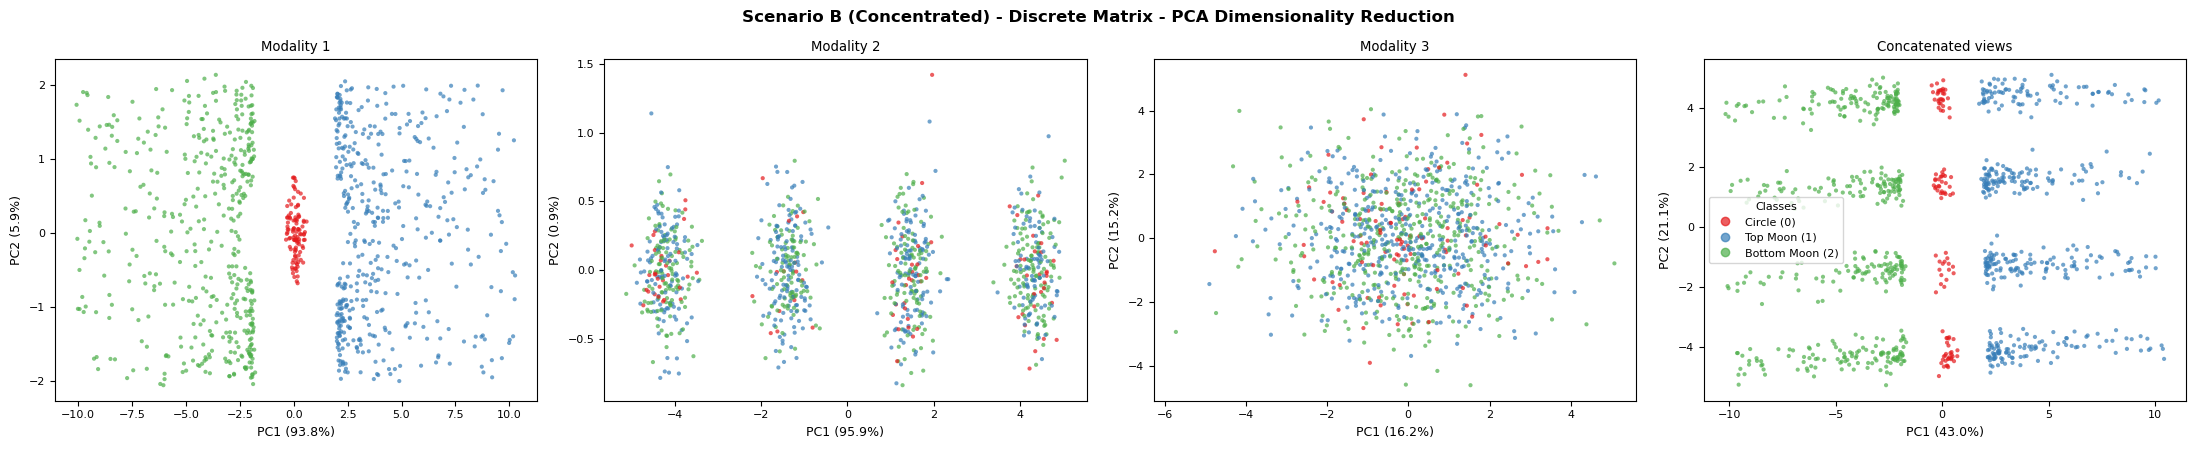

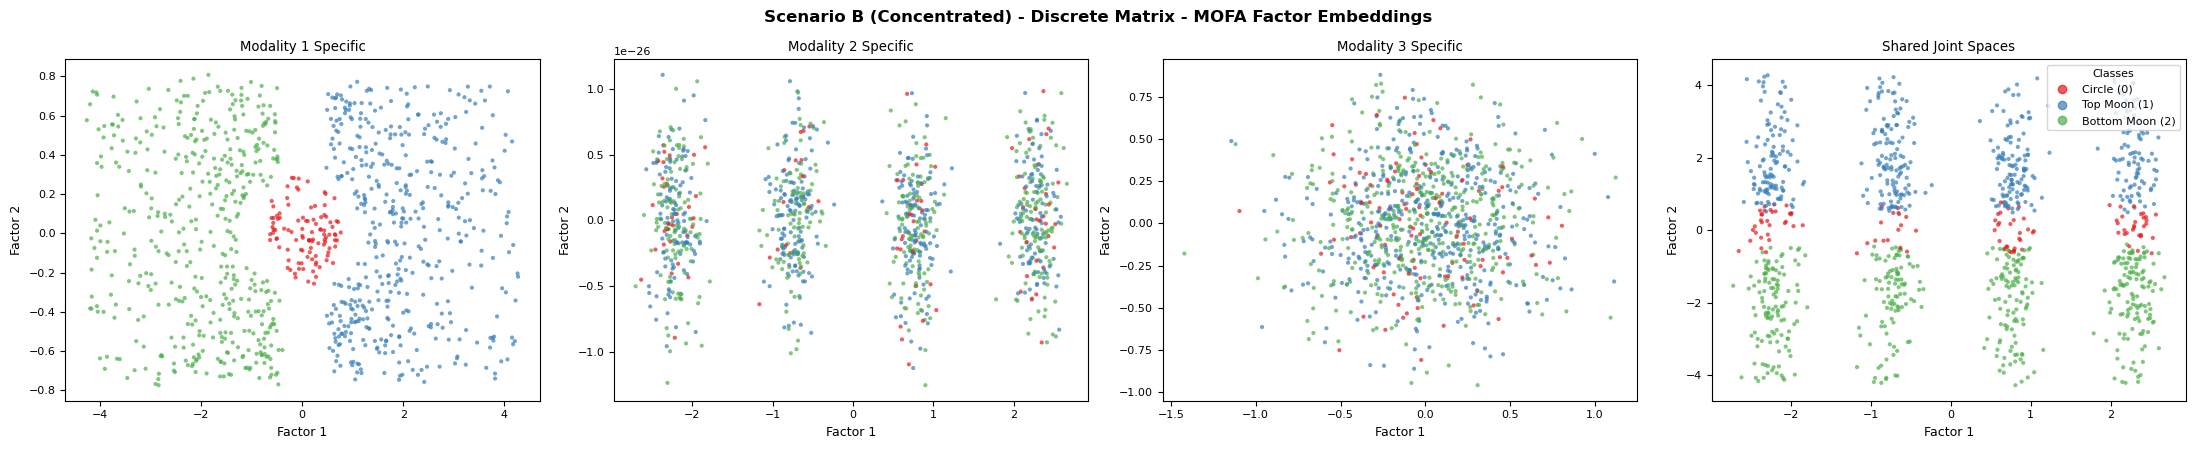


--- Scenario B (Concentrated) - Discrete Matrix Downstream Performance Analysis Table ---
|                    |   Test Accuracy |
|:-------------------|----------------:|
| PCA: Modality 1    |           1     |
| PCA: Modality 2    |           0.428 |
| PCA: Modality 3    |           0.46  |
| PCA: Concatenated  |           1     |
| MOFA: Modality 1   |           0.964 |
| MOFA: Modality 2   |           0.472 |
| MOFA: Modality 3   |           0.42  |
| MOFA: Shared Joint |           0.968 |




In [6]:
## dot size and transparency for consistent plotting
dot_transparency = 0.7
dot_size = 9 

## model configurations
test_size = 0.25
n_comp_pca = 2
n_factors_mofa = 3
#TODO: MAX Tu nie powinno być n_comp_pca == n_factors_mofa??????
discrete_colors = ['#e41a1c', '#377eb8', '#4daf4a']
discrete_cmap = ListedColormap(discrete_colors)

# evaluation helper function
## downstream modeling pipeline
def evaluate_embeddings(X_embeddings, y, is_discrete):
    if is_discrete:
        X_train, X_test, y_train, y_test = train_test_split(
            X_embeddings, y, test_size=test_size, random_state=seed, stratify=y
        )
        clf = LogisticRegression(max_iter=1000, random_state=seed)
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)
        return accuracy_score(y_test, preds)
    else:
        X_train, X_test, y_train, y_test = train_test_split(
            X_embeddings, y, test_size=test_size, random_state=seed
        )
        # Using Random Forest Regressor to capture complex spatial topologies without enforcing linear relationships
        reg = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=seed, n_jobs=-1)
        reg.fit(X_train, y_train)
        preds = reg.predict(X_test)
        return r2_score(y_test, preds)


# execution and plotting helper function
## analytical factory for embedding generation and visualization
def run_full_analysis(m1, m2, m3, y, scenario_title, is_discrete):
    # PCA section
    pca_obj_m1 = PCA(n_components=n_comp_pca, random_state=seed)
    pca_m1 = pca_obj_m1.fit_transform(m1)
    
    pca_obj_m2 = PCA(n_components=n_comp_pca, random_state=seed)
    pca_m2 = pca_obj_m2.fit_transform(m2)
    
    pca_obj_m3 = PCA(n_components=n_comp_pca, random_state=seed)
    pca_m3 = pca_obj_m3.fit_transform(m3)
    
    concat_data = np.hstack([m1, m2, m3])
    pca_obj_concat = PCA(n_components=n_comp_pca, random_state=seed)
    pca_concat = pca_obj_concat.fit_transform(concat_data)
    
    # MOFA section with stdout redirection to completely suppress the big ASCII logo and iterations texts
    mofa_kwargs = {"n_factors": n_factors_mofa, "seed": seed, "quiet": True}
    
    old_stdout = sys.stdout
    sys.stdout = open(os.devnull, 'w')
    try:
        mdata_m1 = mu.MuData({"mod1": sc.AnnData(m1)})
        mu.tl.mofa(mdata_m1, **mofa_kwargs)
        mofa_m1 = mdata_m1.obsm["X_mofa"]
        
        mdata_m2 = mu.MuData({"mod2": sc.AnnData(m2)})
        mu.tl.mofa(mdata_m2, **mofa_kwargs)
        mofa_m2 = mdata_m2.obsm["X_mofa"]
        
        mdata_m3 = mu.MuData({"mod3": sc.AnnData(m3)})
        mu.tl.mofa(mdata_m3, **mofa_kwargs)
        mofa_m3 = mdata_m3.obsm["X_mofa"]
        
        mdata_shared = mu.MuData({"mod1": sc.AnnData(m1), "mod2": sc.AnnData(m2), "mod3": sc.AnnData(m3)})
        mu.tl.mofa(mdata_shared, **mofa_kwargs)
        mofa_shared = mdata_shared.obsm["X_mofa"]
    finally:
        sys.stdout.close()
        sys.stdout = old_stdout
    
    # Downstream evaluation mapping
    embeddings = {
        "PCA: Modality 1": pca_m1, "PCA: Modality 2": pca_m2, "PCA: Modality 3": pca_m3, "PCA: Concatenated": pca_concat,
        "MOFA: Modality 1": mofa_m1, "MOFA: Modality 2": mofa_m2, "MOFA: Modality 3": mofa_m3, "MOFA: Shared Joint": mofa_shared
    }
    
    metric_name = 'Test Accuracy' if is_discrete else 'Test Non-linear R2 (Random Forest)'
    results = {name: evaluate_embeddings(emb, y, is_discrete) for name, emb in embeddings.items()}
    df_res = pd.DataFrame.from_dict(results, orient='index', columns=[metric_name])
    
    # Use all samples for plotting
    plot_idx = np.arange(n_samples)
    cmap_to_use = discrete_cmap if is_discrete else 'coolwarm'
    
    # Plotting row 1: PCA Embeddings
    fig, axes = plt.subplots(1, 4, figsize=(22, 4.5))
    fig.suptitle(f"{scenario_title} - PCA Dimensionality Reduction", fontweight='bold', fontsize=12)
    pca_list = [pca_m1, pca_m2, pca_m3, pca_concat]
    pca_objs = [pca_obj_m1, pca_obj_m2, pca_obj_m3, pca_obj_concat]
    titles_pca = ["Modality 1", "Modality 2", "Modality 3", "Concatenated views"]
    
    for idx, (emb, obj, title) in enumerate(zip(pca_list, pca_objs, titles_pca)):
        scat = axes[idx].scatter(emb[plot_idx, 0], emb[plot_idx, 1], c=y[plot_idx], cmap=cmap_to_use, alpha=dot_transparency, s=dot_size, edgecolor='none')
        axes[idx].set_title(title)
        axes[idx].set_xlabel(f"PC1 ({obj.explained_variance_ratio_[0]*100:.1f}%)")
        axes[idx].set_ylabel(f"PC2 ({obj.explained_variance_ratio_[1]*100:.1f}%)")
        if not is_discrete:
            fig.colorbar(scat, ax=axes[idx], shrink=0.6)
        elif idx == 3:
            handles, _ = scat.legend_elements()
            axes[idx].legend(handles, ['Circle (0)', 'Top Moon (1)', 'Bottom Moon (2)'], title="Classes", loc='best')
    plt.tight_layout()
    plt.show()

    # Plotting row 2: MOFA Embeddings
    fig, axes = plt.subplots(1, 4, figsize=(22, 4.5))
    fig.suptitle(f"{scenario_title} - MOFA Factor Embeddings", fontweight='bold', fontsize=12)
    mofa_list = [mofa_m1, mofa_m2, mofa_m3, mofa_shared]
    titles_mofa = ["Modality 1 Specific", "Modality 2 Specific", "Modality 3 Specific", "Shared Joint Spaces"]
    
    for idx, (emb, title) in enumerate(zip(mofa_list, titles_mofa)):
        scat = axes[idx].scatter(emb[plot_idx, 0], emb[plot_idx, 1], c=y[plot_idx], cmap=cmap_to_use, alpha=dot_transparency, s=dot_size, edgecolor='none')
        axes[idx].set_title(title)
        axes[idx].set_xlabel("Factor 1")
        axes[idx].set_ylabel("Factor 2")
        if not is_discrete:
            fig.colorbar(scat, ax=axes[idx], shrink=0.6)
        elif idx == 3:
            handles, _ = scat.legend_elements()
            axes[idx].legend(handles, ['Circle (0)', 'Top Moon (1)', 'Bottom Moon (2)'], title="Classes", loc='best')
    plt.tight_layout()
    plt.show()
    
    print(f"\n--- {scenario_title} Downstream Performance Analysis Table ---")
    print(df_res.to_markdown())
    print("\n" + "="*80 + "\n")


# execution calls
## running analytical pipelines for all four combinations
run_full_analysis(mod1_a_cont, mod2_a_cont, mod3_a_cont, y_a_cont, "Scenario A (Distributed) - Continuous Matrix", is_discrete=False)
run_full_analysis(mod1_a_disc, mod2_a_disc, mod3_a_disc, y_a_disc, "Scenario A (Distributed) - Discrete Matrix", is_discrete=True)
run_full_analysis(mod1_b_cont, mod2_b_cont, mod3_b_cont, y_b_cont, "Scenario B (Concentrated) - Continuous Matrix", is_discrete=False)
run_full_analysis(mod1_b_disc, mod2_b_disc, mod3_b_disc, y_b_disc, "Scenario B (Concentrated) - Discrete Matrix", is_discrete=True)

---

## Task 2 - Real data of your choice

Pick a public multi-modal dataset with:
- At least two views.
- At least one categorical covariate (subtype, treatment group, tissue type, mutation status, or similar).

Fit MOFA and MOFA/PCA on each single view, then compare their performance on a downstream task using the evaluation strategy from Task 1. Are there any conclusions that can be drawn from the multi-modal model that cannot be drawn from the single-view models?

### TCGA_BRCA data

We choose the data from [TCGA_BRCA](https://portal.gdc.cancer.gov/projects/TCGA-BRCA) and we downloaded already initially preprocessed data from [LinkedOmics](https://www.linkedomics.org/data_download/TCGA-BRCA/):

| OMICS dataset                                                                                                                                                                       | description                                                                                  | level     | unit                           | samples | attributes |
| :---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | :------------------------------------------------------------------------------------------- | :-------- | :----------------------------- | :------ | :--------- |
| [clinical](https://linkedomics.org/data_download/TCGA-BRCA/Human__TCGA_BRCA__MS__Clinical__Clinical__01_28_2016__BI__Clinical__Firehose.tsi)                             |  	Clinical annotation                                                                                   | Clinical  | Phenotype | 1097                           | 19      |
| [RNAseq](https://linkedomics.org/data_download/TCGA-BRCA/Human__TCGA_BRCA__UNC__RNAseq__HiSeq_RNA__01_28_2016__BI__Gene__Firehose_RSEM_log2.cct.gz)                                 | RNAseq data normalized counts (Illumina HiSeq platform, Gene-level, RPKM)                    | gene      | Expression (RSEM, Log2(Val+1)) | 1093    | 20155      |
| [methylation data]( https://linkedomics.org/data_download/TCGA-BRCA/Human__TCGA_BRCA__JHU_USC__Methylation__Meth450__01_28_2016__BI__Gene__Firehose_Methylation_Prepocessor.cct.gz) | Methylation data of tumor samples at Gene level (Beta values, Illumina HM450K platform)      | gene      | Beta Values (Val-0.5)          | 783     | 20106      |
| [miRNA](https://linkedomics.org/data_download/TCGA-BRCA/Human__TCGA_BRCA__BDGSC__miRNASeq__HS_miR__01_28_2016__BI__Gene__Firehose_RPKM_log2.cct)                                    | miRNA expression for tumor samples (Illumina HiSeq platform, Normalized, miRgene-level, RPM) | miRgene   | Expression (RPM, Log2(Val+1))  | 755     | 823        |

---

### Results

In the **TCGA-BRCA** dataset, all embeddings were evaluated with the same hold-out strategy as in Task 1: a 75/25 train-test split with a fixed random seed. Logistic regression was trained on each low-dimensional representation, and the main comparison was based on balanced accuracy and macro F1 because the PAM50 classes were imbalanced.

The best performance was obtained by the **MOFA model fitted only on RNA-seq** data, with balanced accuracy of **0.865** and macro F1 of **0.834**. The second-best result was obtained by **PCA on RNA-seq**, with balanced accuracy of **0.851** and macro F1 of **0.809**. This shows that RNA-seq contains the strongest PAM50 classification signal among the tested views.

The multi-view models performed slightly worse than the RNA-seq-only models. **PCA on concatenated data** reached balanced accuracy of **0.802**, while **MOFA_shared** reached **0.793**. This means that adding methylation and miRNA did not improve classification performance in this setup. Methylation still contained useful subtype-related information, but its performance was lower than RNA-seq. miRNA was the weakest view.

These results are biologically accteptable because PAM50 subtypes are primarily defined by gene expression profiles. Therefore, RNA-seq is expected to be the most informative view. The confusion matrix for the best model, **MOFA_RNAseq**, shows good separation of Basal and LumA samples, while most errors occur between Her2 and Luminal subtypes, especially LumB and LumA.


---

In [7]:
# Download data

!mkdir -p data

#Annotation
!wget -O data/clinical_annotation.txt https://linkedomics.org/data_download/TCGA-BRCA/Human__TCGA_BRCA__MS__Clinical__Clinical__01_28_2016__BI__Clinical__Firehose.tsi

# View 1
!wget -O data/RNAseq.txt.gz https://linkedomics.org/data_download/TCGA-BRCA/Human__TCGA_BRCA__UNC__RNAseq__HiSeq_RNA__01_28_2016__BI__Gene__Firehose_RSEM_log2.cct.gz


# View 2
!wget -O data/methylation.txt.gz https://linkedomics.org/data_download/TCGA-BRCA/Human__TCGA_BRCA__JHU_USC__Methylation__Meth450__01_28_2016__BI__Gene__Firehose_Methylation_Prepocessor.cct.gz


# View 3
!wget -O data/miRNA.txt https://linkedomics.org/data_download/TCGA-BRCA/Human__TCGA_BRCA__BDGSC__miRNASeq__HS_miR__01_28_2016__BI__Gene__Firehose_RPKM_log2.cct


!gunzip data/*.gz

--2026-06-05 20:08:27--  https://linkedomics.org/data_download/TCGA-BRCA/Human__TCGA_BRCA__MS__Clinical__Clinical__01_28_2016__BI__Clinical__Firehose.tsi
Resolving linkedomics.org (linkedomics.org)... 104.21.42.206, 172.67.210.18, 2606:4700:3033::6815:2ace, ...
Connecting to linkedomics.org (linkedomics.org)|104.21.42.206|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 150963 (147K)
Saving to: ‘data/clinical_annotation.txt’

data/clinical_annot 100%[===================>] 147.42K   261KB/s    in 0.6s    

2026-06-05 20:08:29 (261 KB/s) - ‘data/clinical_annotation.txt’ saved [150963/150963]

--2026-06-05 20:08:30--  https://linkedomics.org/data_download/TCGA-BRCA/Human__TCGA_BRCA__UNC__RNAseq__HiSeq_RNA__01_28_2016__BI__Gene__Firehose_RSEM_log2.cct.gz
Resolving linkedomics.org (linkedomics.org)... 104.21.42.206, 172.67.210.18, 2606:4700:3033::6815:2ace, ...
Connecting to linkedomics.org (linkedomics.org)|104.21.42.206|:443... connected.
HTTP request sent, awaiti

# Files structure

All downloaded LinkedOmics files have a similar orientation:

- columns correspond to TCGA samples,
- rows correspond to features or annotations,
- the first column `attrib_name` stores feature names.

Therefore, after loading the files, all matrices need to be transposed so that rows represent samples and columns represent variables/features. This orientation is required by scikit-learn, PCA, logistic regression and most machine learning tools.

## clinical_annotation.txt

```txt
attrib_name              sample1     sample2     sample3 ...
years_to_birth           ...
Tumor_purity             ...
pathologic_stage         ...
PAM50                    ...
ER.Status                ...
PR.Status                ...
HER2.Status              ...
overall_survival         ...
```

- columns - samples
- rows - clinical annotations / phenotypic traits
- PAM50 - target variable for cancer subtype classification



## RNAseq.txt

```txt
attrib_name     sample1     sample2     sample3 ...
A1BG            7.63        7.8971      ...
A1CF            0           0           ...
A2BP1           0           0           ...
```
- columns - samples
- rows - genes
- values - gene expression values, already log-transformed
- biological view: transcriptome / mRNA expression

## methylation.txt

```txt
attrib_name     sample1     sample2     sample3 ...
RBL2            -0.4444     -0.4313     ...
VDAC3           -0.4548     -0.4692     ...
ACTN1            0.2310      0.2859     ...
```
- columns - samples
- rows - genes
- values - gene-level DNA methylation beta values shifted by -0.5
- biological view: epigenomic regulation


## miRNA.txt

```txt
attrib_name     sample1     sample2     sample3 ...
hsa-let-7a-1    13.1299     12.9183     ...
hsa-let-7a-2    14.1180     13.9224     ...
hsa-let-7b      14.5952     14.5127     ...
```
- columns - samples
- rows - miRNA genes
- values - miRNA expression values, log2(RPM + 1)
- biological view: post-transcriptional regulation

## Data loading and preprocessing

The TCGA-BRCA multi-omics data were downloaded from [LinkedOmics](https://www.linkedomics.org/data_download/TCGA-BRCA/). The original files store samples in columns and molecular features or clinical annotations in rows. Since scikit-learn expect samples in rows and features in columns, all matrices were transposed after loading.

PAM50 molecular subtype was selected as the classification target because it represents established breast cancer molecular subtypes and provides a biologically meaningful multiclass label. Samples without PAM50 annotation were removed. We then retained only samples shared across RNAseq, DNA methylation, miRNA and clinical annotation to ensure that all models were trained and evaluated on exactly the same samples.

### PCA

In [8]:
################################################################################
# IMPORTS AND GLOBAL PARAMETERS
################################################################################

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, f1_score, accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import make_pipeline

from mofapy2.run.entry_point import entry_point

################################################################################
# READ DATA
################################################################################

data_names = ["clinical_annotation", "methylation", "miRNA", "RNAseq"]
raw_data = {}
print()
print("Data shapes before transformation:")

for name in data_names:
    path = Path(f"data/{name}.txt")
    
    # The first column stores feature or annotation names.
    df = pd.read_csv(path, sep="\t", index_col=0)

    raw_data[name] = df
    print(f"{name}: {df.shape}")
    
print()

################################################################################
# TRANSPOSE MATRIX
################################################################################
# Original orientation:
# rows = features / annotations
# columns = samples
#
# Required orientation for scikit-learn:
# rows = samples
# columns = features / annotations
print()
transformed_data = {
    name: df.T for name, df in raw_data.items()
}

clinical = transformed_data["clinical_annotation"]

views = {
    "RNAseq": transformed_data["RNAseq"],
    "methylation": transformed_data["methylation"],
    "miRNA": transformed_data["miRNA"],
}

print("Data shapes after transposition:")

print(f"clinical_annotation: {clinical.shape}")

for view_name, x in views.items():
    print(f"{view_name}: {x.shape}")
print()

################################################################################
# PREPARE TARGET PAM50
################################################################################
# choose PAM50 as a classification target.
pam50 = clinical["PAM50"]
pam50 = pam50.replace("NA", pd.NA)

print()
print("PAM50 class distribution before removing missing labels:")
print(pam50.value_counts(dropna=False))

# Remove samples without PAM50 annotation.
pam50 = pam50.dropna()

print("PAM50 class distribution after removing missing labels:")
print(pam50.value_counts())

print("\nPAM50 class proportions:")
print(pam50.value_counts(normalize=True))
print()

################################################################################
# FIND COMMON SAMPLES
################################################################################
# Only samples present in all omics views and in the clinical annotation can be used for multi view analysis- find common part.

sample_sets = [set(pam50.index)]

for x in views.values():
    sample_sets.append(set(x.index))

common_samples = sorted(set.intersection(*sample_sets))
print()
print("Common samples:", len(common_samples))


print()



################################################################################
# FILTER DATA TO COMMON SAMPLES
################################################################################
# Target vector for common samples.
y = pam50.loc[common_samples]

# Filter each omics view to the same common samples.
filtered_views = {}

for view_name, x in views.items():
    filtered_views[view_name] = x.loc[common_samples]
print()
print("Shapes after sample filtering:")

print(f"y: {y.shape}")
for view_name, x in filtered_views.items():
    print(f"{view_name}: {x.shape}")

print()

################################################################################
# CONTROL DATA
################################################################################
# Check whether all views contain the same number of samples and whether sample order is identical to the target vector.

for view_name, x in filtered_views.items():
    if x.shape[0] != len(y):
        raise ValueError(
            f"Sample number mismatch for {view_name}: "
            f"{x.shape[0]} != {len(y)}"
        )
    
    if not x.index.equals(y.index):
        raise ValueError(f"Sample order mismatch for {view_name}")
    

################################################################################
# CONVERT DATA TO NUMERIC FORMAT - MAKE SURE
################################################################################
# Omics matrices should contain only numeric values.

numeric_views = {}

for view_name, x in filtered_views.items():
    numeric_views[view_name] = x.apply(pd.to_numeric, errors="coerce")


################################################################################
# FILL MISSING VALUES
################################################################################
print()
print("Missing values before imputation:")

for view_name, x in numeric_views.items():
    missing_fraction = x.isna().mean().mean()
    missing_count = x.isna().sum().sum()
    
    print(f"{view_name}:")
    print(f"\tmissing fraction: {missing_fraction:.4f}")
    print(f"\tmissing count: {missing_count}")


print()
    
# Remaining missing values are imputed with feature-wise medians. This preserves all samples while avoiding leakage between features.

imputed_views = {}

for view_name, x in numeric_views.items():
    imputed_views[view_name] = x.fillna(x.median())

# Verify that no missing values remain.
for view_name, x in imputed_views.items():
    if x.isna().sum().sum() != 0:
        raise ValueError(f"Improper NaN imputation in {view_name}")




Data shapes before transformation:


clinical_annotation: (20, 1097)
methylation: (20106, 783)
miRNA: (823, 755)
RNAseq: (20155, 1093)


Data shapes after transposition:
clinical_annotation: (1097, 20)
RNAseq: (1093, 20155)
methylation: (783, 20106)
miRNA: (755, 823)


PAM50 class distribution before removing missing labels:
PAM50
LumA     426
NaN      271
LumB     186
Basal    147
Her2      67
Name: count, dtype: int64
PAM50 class distribution after removing missing labels:
PAM50
LumA     426
LumB     186
Basal    147
Her2      67
Name: count, dtype: int64

PAM50 class proportions:
PAM50
LumA     0.515738
LumB     0.225182
Basal    0.177966
Her2     0.081114
Name: proportion, dtype: float64


Common samples: 430


Shapes after sample filtering:
y: (430,)
RNAseq: (430, 20155)
methylation: (430, 20106)
miRNA: (430, 823)


Missing values before imputation:
RNAseq:
	missing fraction: 0.0000
	missing count: 0
methylation:
	missing fraction: 0.0003
	missing count: 2758
miRNA:
	missing fraction: 0.0000
	missing count: 0



In [9]:

################################################################################
# SELECT MOST DIVERGENT FEATURES
################################################################################
def select_top_variable_features(x, ntop):
    """
    Select features with the highest variance across samples. This reduces dimensionality before PCA/MOFA while retaining the most variable molecular signals.
    """
    ntop = min(ntop, x.shape[1])
    variances = x.var(axis=0)
    top_features = variances.sort_values(ascending=False).head(ntop).index
    
    return x.loc[:, top_features]

selected_views = {}
print()

for view_name, x in imputed_views.items():
    
    # RNAseq and methylation have many features, so we keep top 2000. miRNA has fewer features, so 500 is enouht.
    if view_name == "miRNA":
        ntop = 500
    else:
        ntop = 2000
    
    selected_views[view_name] = select_top_variable_features(x, ntop=ntop)
    
    print(f"{view_name}: {selected_views[view_name].shape}")
    
print()  
################################################################################
# STANDARIZE VIEWS
################################################################################
# Each omics view is scaled independently. This prevents one view from dominating PCA/MOFA due to a larger numeric range.

final_views = {}

for view_name, x in selected_views.items():
    scaler = StandardScaler()
    
    x_scaled = scaler.fit_transform(x)
    
    final_views[view_name] = pd.DataFrame(
        x_scaled,
        index=x.index,
        columns=x.columns
    )
print()
print("Scaled view summaries:")

for view_name, x in final_views.items():
    print(f"{view_name}:")
    print(f"  shape: {x.shape}")
    print(f"  mean: {x.mean().mean():.4f}")
    print(f"  std: {x.std().mean():.4f}")
print()

################################################################################
# DOUBLE CHECK - FINAL VARIABLES
################################################################################
x_rna_scaled = final_views["RNAseq"]
x_methylation_scaled = final_views["methylation"]
x_mirna_scaled = final_views["miRNA"]

assert x_rna_scaled.index.equals(y.index)
assert x_methylation_scaled.index.equals(y.index)
assert x_mirna_scaled.index.equals(y.index)

assert x_rna_scaled.shape[0] == x_methylation_scaled.shape[0]
assert x_rna_scaled.shape[0] == x_mirna_scaled.shape[0]
assert x_rna_scaled.shape[0] == y.shape[0]




RNAseq: (430, 2000)
methylation: (430, 2000)
miRNA: (430, 500)


Scaled view summaries:
RNAseq:
  shape: (430, 2000)
  mean: -0.0000
  std: 1.0012
methylation:
  shape: (430, 2000)
  mean: 0.0000
  std: 1.0012
miRNA:
  shape: (430, 500)
  mean: 0.0000
  std: 1.0012



## Preprocessing strategy

After matching samples across all views, each omics matrix was processed independently. Molecular values were converted to numeric format and non-numeric entries were treated as missing values. Remaining missing values were imputed using feature-wise medians.

To reduce dimensionality before PCA and MOFA, we selected the most variable molecular features within each omics view. This step removes low-variance features that are unlikely to contribute strongly to subtype separation and reduces computational burden. RNAseq and DNA methylation were filtered to the top 2000 most variable features, while miRNA was filtered to the top 500 most variable features due to its smaller original feature space.

Finally, each view was standardized independently. This is important because RNA expression, DNA methylation and miRNA expression are measured on different numerical scales. Independent scaling prevents one omics layer from dominating the latent representation only because of its larger variance or numeric range. Final consistency checks confirmed that all views and the PAM50 target vector contained the same samples in the same order.

In [10]:
################################################################################
# GLOBAL SETTINGS
################################################################################

SEED = 1946
K = 5 # Number of latent dimensions (PCA components or MOFA factors)

RESULTS_DIR = Path("results_task2")
RESULTS_DIR.mkdir(exist_ok=True)


################################################################################
# PCA - HELPER FUNCTION
################################################################################
from sklearn.decomposition import PCA
def fit_pca_embedding(x, n_components, prefix):
    """
    Fit PCA to one data matrix and return:
    - low-dimensional embedding,
    - fitted PCA model.
    """
    pca = PCA(n_components=n_components, random_state=SEED)
    z = pca.fit_transform(x)

    embedding = pd.DataFrame(
        z,
        index=x.index,
        columns=[f"{prefix}_PC{i+1}" for i in range(n_components)]
    )

    return embedding, pca

################################################################################
# PCA - SINGLE-VIEW MODELS
################################################################################

pca_embeddings = {}
pca_models = {}

for view_name, x in final_views.items():
    embedding, model = fit_pca_embedding(
        x=x,
        n_components=K,
        prefix=view_name
    )

    pca_embeddings[f"PCA_{view_name}"] = embedding
    pca_models[f"PCA_{view_name}"] = model

    explained = model.explained_variance_ratio_.sum()
    print(f"PCA {view_name}")
    print(f"\tembedding shape: {embedding.shape}")
    print(f"\texplained variance by first {K} PCs: {explained:.4f}")
    print()


################################################################################
# PCA - CONCATENATED MULTI-VIEW BASELINE
################################################################################

x_concat = pd.concat(
    final_views.values(),
    axis=1,
    keys=final_views.keys()
)

################################################################################
# PCA - FLATTEN CONCATENATED COLUMN NAMES
################################################################################

x_concat.columns = [
    f"{view}_{feature}"
    for view, feature in x_concat.columns
]
print()
print("Concatenated data shape:", x_concat.shape)
print()

################################################################################
# PCA - FIT CONCATENATED MODEL
################################################################################

embedding_concat, model_concat = fit_pca_embedding(
    x=x_concat,
    n_components=K,
    prefix="Concatenated"
)

pca_embeddings["PCA_concatenated"] = embedding_concat
pca_models["PCA_concatenated"] = model_concat
print()
print("PCA concatenated")
print(f"\tembedding shape: {embedding_concat.shape}")
print(f"\texplained variance by first {K} PCs: {model_concat.explained_variance_ratio_.sum():.4f}")
print()

################################################################################
# PCA - EXPLAINED VARIANCE TABLE
################################################################################

pca_variance_rows = []

for model_name, model in pca_models.items():
    row = {
        "model": model_name,
        "total_explained_variance": model.explained_variance_ratio_.sum()
    }

    for i, value in enumerate(model.explained_variance_ratio_, start=1):
        row[f"PC{i}_explained_variance"] = value

    pca_variance_rows.append(row)

pca_variance_df = pd.DataFrame(pca_variance_rows)
pca_variance_df 


################################################################################
# CLASSIFICATION - HELPER FUNCTION
################################################################################
def evaluate_embedding_holdout(
    embedding,
    labels,
    model_name,
    test_size=0.25,
    seed=42
):
    """
    Evaluate a low-dimensional embedding on the PAM50 classificatio
    """

    # Encode class labels
    le = LabelEncoder()
    y = le.fit_transform(labels)

    # Same evaluation strategy as in Task 1
    X_train, X_test, y_train, y_test = train_test_split(
        embedding,
        y,
        test_size=test_size,
        random_state=seed,
        stratify=y
    )

    clf = LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=seed
    )

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "macro_f1": f1_score(y_test, y_pred, average="macro")
    }

    return results



PCA RNAseq
	embedding shape: (430, 5)
	explained variance by first 5 PCs: 0.3406

PCA methylation
	embedding shape: (430, 5)
	explained variance by first 5 PCs: 0.4241

PCA miRNA
	embedding shape: (430, 5)
	explained variance by first 5 PCs: 0.3769


Concatenated data shape: (430, 4500)


PCA concatenated
	embedding shape: (430, 5)
	explained variance by first 5 PCs: 0.3273



The PAM50 signal is present in more than one omics layer, but the predictive information is not evenly distributed across views. RNAseq provides the strongest single-view representation and performs almost as well as the concatenated multi-view PCA model. Methylation and miRNA also contain subtype-related information, but their downstream performance is lower. Therefore, the results suggest partial multi-omic redundancy rather than a clear advantage of multi-modal integration.

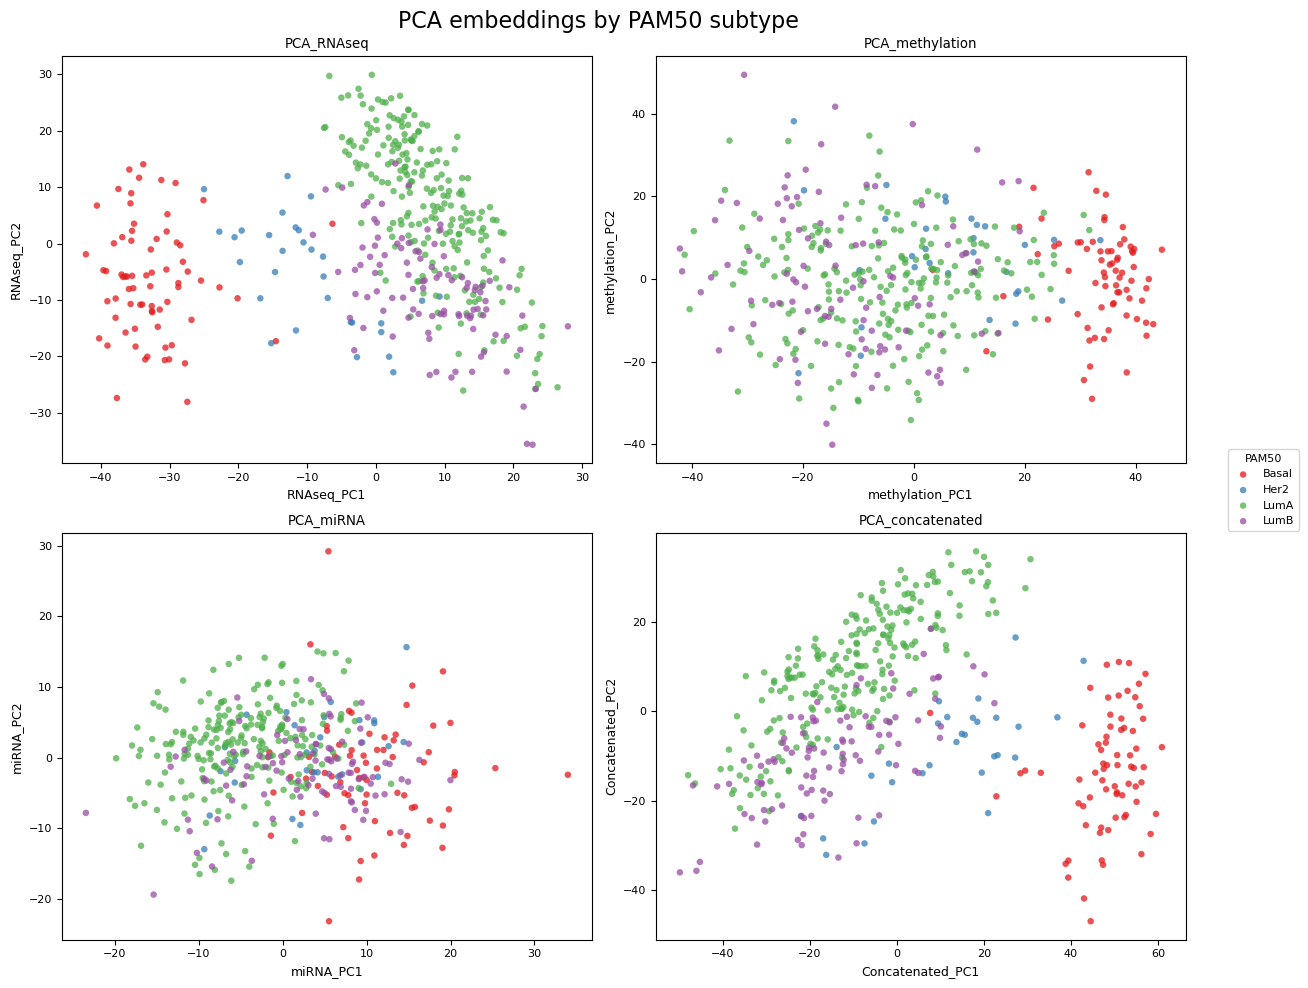

In [11]:
################################################################################
# VISUALIZATION - MULTIPLE EMBEDDINGS SIDE BY SIDE
################################################################################

def plot_embeddings_grid(embeddings, y, title, ncols=2):
    """
    Plot multiple 2D embeddings in a grid. Each embedding is shown using its first two dimensions. Points are colored by PAM50 subtype.
    """
    n_plots = len(embeddings)
    nrows = int(np.ceil(n_plots / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(6 * ncols, 5 * nrows),
        squeeze=False
    )

    labels = sorted(y.unique())
    cmap = plt.get_cmap("Set1")
    color_map = {
		label: cmap(i)
		for i, label in enumerate(labels)
	}

    for ax, (model_name, embedding) in zip(axes.ravel(), embeddings.items()):
        x_col = embedding.columns[0]
        y_col = embedding.columns[1]

        for label in labels:
            mask = y == label

            ax.scatter(
                embedding.loc[mask, x_col],
                embedding.loc[mask, y_col],
                label=label,
                color=color_map.get(label, "gray"),
                alpha=0.75,
                s=22,
                edgecolor="none"
            )

        ax.set_title(model_name)
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)

    # Hide unused axes
    for ax in axes.ravel()[n_plots:]:
        ax.set_visible(False)

    handles, legend_labels = axes.ravel()[0].get_legend_handles_labels()

    fig.legend(
        handles,
        legend_labels,
        title="PAM50",
        bbox_to_anchor=(1.02, 0.5),
        loc="center left"
    )

    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.style.use("ggplot")
    plt.show()
    
################################################################################
# VISUALIZATION - PCA EMBEDDINGS GRID
################################################################################

plot_embeddings_grid(
    embeddings=pca_embeddings,
    y=y,
    title="PCA embeddings by PAM50 subtype",
    ncols=2
)

### MOFA

In [12]:


################################################################################
# MOFA - HELPER FUNCTION
################################################################################

def fit_mofa_embedding(views_dict, n_factors, model_name, output_dir):
    """
    Fit MOFA model on one or multiple omics views.

    Parameters
    ----------
    views_dict:
        Dictionary with view names as keys and sample-by-feature matrices as values.
    n_factors:
        Number of latent factors.
    model_name:
        Name used for saved output file.
    output_dir:
        Directory where MOFA output file will be saved.

    Returns
    -------
    embedding:
        DataFrame with samples in rows and MOFA factors in columns.
    """

    view_names = list(views_dict.keys())
    group_names = ["group1"]

    reference_samples = list(views_dict[view_names[0]].index)

    for view in view_names:
        if list(views_dict[view].index) != reference_samples:
            raise ValueError(f"Sample order mismatch in view: {view}")

    data = [[views_dict[view].to_numpy(dtype=float)] for view in view_names
    ]

    samples_names = [reference_samples]

    features_names = [
        [f"{view}_{feature}" for feature in views_dict[view].columns]
        for view in view_names
    ]

    ent = entry_point()

    ent.set_data_options( scale_views=False, scale_groups=False
    )

    ent.set_data_matrix( data=data, views_names=view_names, groups_names=group_names, samples_names=samples_names, features_names=features_names )

    ent.set_model_options( factors=n_factors)

    ent.set_train_options(iter=1000, convergence_mode="fast", seed=SEED
    )

    ent.build()
    ent.run()

    output_path = output_dir / f"{model_name}.hdf5"
    ent.save(str(output_path))

    z = ent.model.nodes["Z"].getExpectation()
    z = np.asarray(z)

    if z.shape[0] == n_factors:
        z = z.T

    embedding = pd.DataFrame(
        z,
        index=reference_samples,
        columns=[f"{model_name}_Factor{i+1}" for i in range(z.shape[1])]
    )

    return embedding



################################################################################
# MOFA - SINGLE-VIEW MODELS
################################################################################

mofa_embeddings = {}
for view_name, x in final_views.items():
    print(f"fitting MOFA single view model for {view_name}")
    
    embedding = fit_mofa_embedding(
        views_dict = {view_name: x},
        n_factors= K,
        model_name = f"MOFA_{view_name}",
        output_dir= RESULTS_DIR
    )
    
    mofa_embeddings[f'MOFA_{view_name}'] = embedding
    
    print(f'\tembedding shape: {embedding.shape}')
    
    
################################################################################
# MOFA - SHARED MULTI VIEW MODELS
################################################################################
print(f'Filtering shared multi view MOFA model')
embedding_shared = fit_mofa_embedding(
    views_dict=final_views,
    n_factors=K,
    model_name = "MOFA_shared",
    output_dir = RESULTS_DIR
)

mofa_embeddings['MOFA_shared'] = embedding_shared

print(f"MODA shared embedding shape: {embedding_shared.shape}")


################################################################################
# MOFA - DOUBLE CHECK EMBEDDINGS
################################################################################
for model_name, embedding in mofa_embeddings.items():
    print(model_name, embedding.shape)

    assert embedding.index.equals(y.index), f"Sample order mismatch in {model_name}"
    assert embedding.shape[0] == len(y), f"Sample count mismatch in {model_name}"
    assert embedding.isna().sum().sum() == 0, f"Missing values in {model_name}"


fitting MOFA single view model for RNAseq

        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         


Successfully loaded view='RNAseq' group='group1' with N=430 samples and D=2000 features...


Model options:
- Automatic Relevance Determination prior on the factors: False
- Automatic Relevance Determination prior on the weights: True
- Spike-and-slab prior on the factors: False
- Spike-and-slab prior on the weights: True
Likelihoods:
- View 0 

## Concatenate PCA vs MOFA results

All evaluated embeddings:
PCA_RNAseq (430, 5)
PCA_methylation (430, 5)
PCA_miRNA (430, 5)
PCA_concatenated (430, 5)
MOFA_RNAseq (430, 5)
MOFA_methylation (430, 5)
MOFA_miRNA (430, 5)
MOFA_shared (430, 5)


,model,accuracy,balanced_accuracy,macro_f1
4,MOFA_RNAseq,0.851852,0.865387,0.834475
0,PCA_RNAseq,0.842593,0.855387,0.817485
3,PCA_concatenated,0.842593,0.801659,0.796832
7,MOFA_shared,0.824074,0.792887,0.787823
5,MOFA_methylation,0.750000,0.756594,0.738231
1,PCA_methylation,0.750000,0.750980,0.729942
2,PCA_miRNA,0.731481,0.675607,0.639920
6,MOFA_miRNA,0.731481,0.669993,0.634097


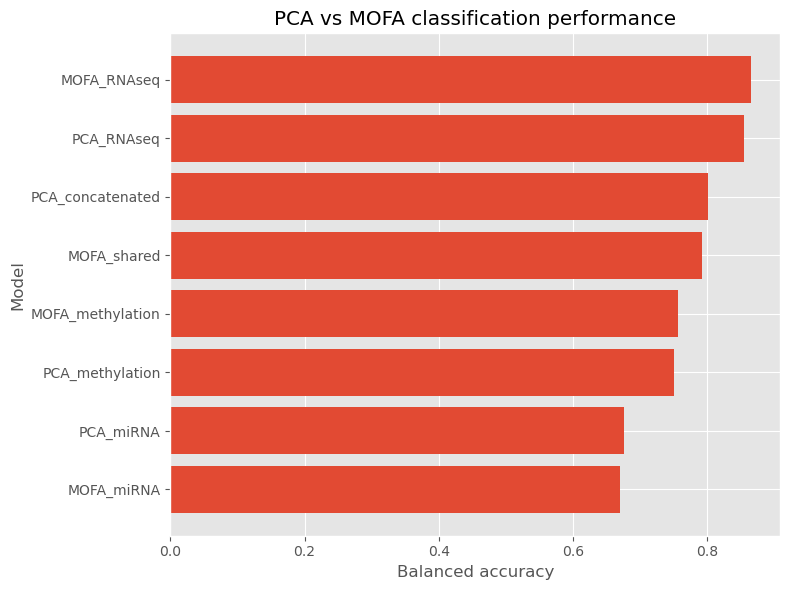

Best model: MOFA_RNAseq


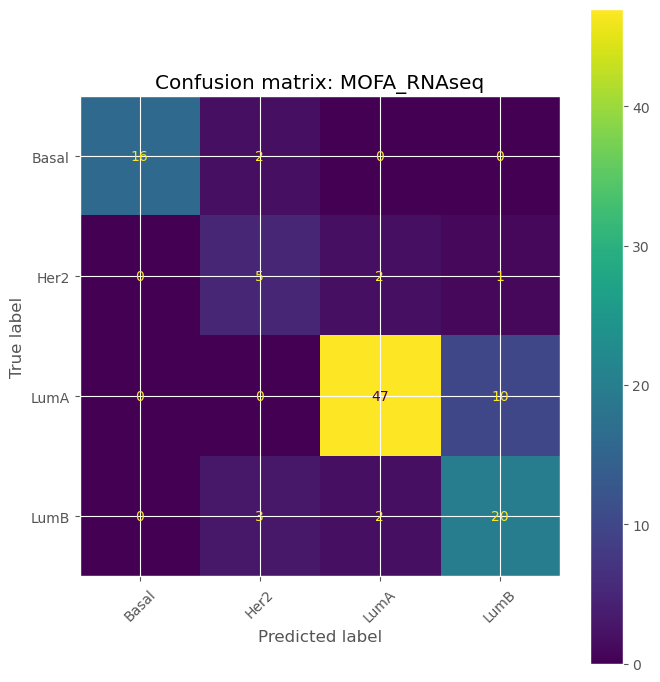

In [13]:
################################################################################
# FINAL COMPARISON - COMBINE ALL EMBEDDINGS
################################################################################

all_embeddings = {}

all_embeddings.update(pca_embeddings)
all_embeddings.update(mofa_embeddings)

print("All evaluated embeddings:")

for model_name, embedding in all_embeddings.items():
    print(model_name, embedding.shape)
    
################################################################################
# FINAL COMPARISON - CLASSIFICATION RESULTS
################################################################################

all_results = []

for model_name, embedding in all_embeddings.items():
    result = evaluate_embedding_holdout(
        embedding=embedding,
        labels=y,
        model_name=model_name,
        test_size=0.25,
        seed=SEED
    )
    all_results.append(result)

results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values("balanced_accuracy", ascending=False)

display(results_df)

results_df.to_csv(
    RESULTS_DIR / "final_pca_vs_mofa_classification_results.csv",
    index=False
)

################################################################################
# FINAL COMPARISON - BARPLOT
################################################################################

plot_df = results_df.sort_values("balanced_accuracy", ascending=True)

plt.figure(figsize=(8, 6))

plt.barh(
    plot_df["model"],
    plot_df["balanced_accuracy"]
)

plt.xlabel("Balanced accuracy")
plt.ylabel("Model")
plt.title("PCA vs MOFA classification performance")
plt.tight_layout()
plt.show()

################################################################################
# FINAL COMPARISON - BEST MODEL SELECTION
################################################################################

best_model_name = results_df.iloc[0]["model"]
best_embedding = all_embeddings[best_model_name]

print("Best model:", best_model_name)



################################################################################
# FINAL COMPARISON - CONFUSION MATRIX FOR BEST MODEL
################################################################################

x_train, x_test, y_train, y_test = train_test_split(
    best_embedding,
    y,
    test_size=0.25,
    stratify=y,
    random_state=SEED
)

clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=SEED
    )
)

clf.fit(x_train, y_train)

y_pred = clf.predict(x_test)

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=sorted(y.unique())
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=sorted(y.unique())
)

fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, xticks_rotation=45)
plt.title(f"Confusion matrix: {best_model_name}")
plt.tight_layout()
plt.show()


################################################################################
# SAVE EMBEDDINGS
################################################################################

for model_name, embedding in all_embeddings.items():
    output_path = RESULTS_DIR / f"{model_name}_embedding.csv"
    embedding.to_csv(output_path)


## Overall results

Overall, the results suggest that the PAM50 signal is present in several omics layers, but it is dominated by RNA-seq. In this dataset, multi-view integration does not provide a clear predictive advantage over the best single-view model. The main conclusion is therefore that multi-view integration is not automatically better than single-view analysis; it is most useful when complementary information is truly distributed across views.

## Comparison to analysis 1. 

We can observe here same results as in analysis 1b. that is dropping score on multimodal data, if information in modalities is not balanced. Precisely described in [Task 1 Concentrated signal](#concentrated-signal)